# 🎬 Netflix Comprehensive Data Dashboard: 18 Khung Hình Trực Quan Hóa
### **Phân Tích Chuyên Sâu Tập Dữ Liệu Netflix (8.807 Tác Phẩm)**
**Dự án:** Trực quan hóa dữ liệu và xây dựng Dashboard thông minh  
**Nhóm 8 - KADA** | **Thành viên:** Phạm Nguyễn Hải Triều, Lương Võ Khôi Quốc, Mô Ha Mách Bu Ba Ka, Trần Quốc Huy, Nguyễn Chí Thịnh

---

## 📌 Giới Thiệu & Mục Tiêu Nghiên Cứu
Notebook này hiện thực hóa toàn bộ **18 biểu đồ trực quan hóa** từ tập dữ liệu đã làm sạch `netflix_titles_cleaned.csv`, được phân chia thành **7 nhóm chủ đề chiến lược**:

1. **Nhóm 1 — Tổng quan nội dung (Overview):** Cơ cấu Movie/TV Show và bản đồ địa lý sản xuất.
2. **Nhóm 2 — Xu hướng theo thời gian (Trends over Time):** Tốc độ tăng trưởng, seasonal heatmap 12 tháng × nhiều năm.
3. **Nhóm 3 — Thể loại & Phân loại độ tuổi (Genre & Rating):** Top thể loại thịnh hành và ma trận khán giả theo độ tuổi.
4. **Nhóm 4 — Thời lượng & Số mùa phát sóng (Duration & Seasons):** Phân phối phút phim lẻ và tỷ lệ sống sót của các series.
5. **Nhóm 5 — Phân tích địa lý & Năm phát hành (Geography & Release Year):** Bản đồ tương tác toàn cầu và độ trễ phát hành.
6. **Nhóm 6 — Đạo diễn & Quy mô dàn diễn viên (Directors & Cast):** Top đạo diễn và độ lớn dàn cast theo thể loại.
7. **Nhóm 7 — Phân tích nâng cao & Khai phá văn bản (Advanced & NLP):** Tương quan thời lượng theo năm, Treemap phân cấp, và Word Cloud cốt truyện.

> **Bộ màu chủ đạo (Netflix Aesthetic Palette):**  
> - Đỏ đặc trưng Netflix: `#E50914` & `#B81D24`  
> - Đen điện ảnh / Nền tối: `#141414` & `#221F1F`  
> - Xanh công nghệ & Nhấn: `#0071EB` & `#E5A00D`

## ⚙️ Phần 0: Cài Đặt Môi Trường, Thư Viện & Cấu Hình Thẩm Mỹ

In [1]:
# Thiết lập môi trường và nạp các thư viện cần thiết
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Thư viện nâng cao (Plotly & WordCloud)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

try:
    from wordcloud import WordCloud, STOPWORDS
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False

# Cấu hình phong cách biểu đồ Netflix hiện đại
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI']
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Bảng màu thương hiệu Netflix
NETFLIX_RED = '#E50914'
NETFLIX_DARK_RED = '#B81D24'
NETFLIX_BLACK = '#141414'
NETFLIX_GRAY = '#221F1F'
NETFLIX_LIGHT_GRAY = '#F5F5F1'
ACCENT_BLUE = '#0071EB'
ACCENT_GOLD = '#E5A00D'
ACCENT_CYAN = '#17A2B8'

print("Đã tải xong toàn bộ thư viện & cấu hình giao diện thành công!")


Đã tải xong toàn bộ thư viện & cấu hình giao diện thành công!


## 📥 Phần 1: Nạp và Khảo Sát Dữ Liệu Đã Làm Sạch

In [2]:
# Tự động tìm đường dẫn file dữ liệu tối ưu
data_candidates = [
    'netflix_titles_cleaned.csv',
    os.path.join('Nhom8', 'netflix_titles_cleaned.csv'),
    os.path.join(os.path.dirname(os.path.abspath('__file__')), 'netflix_titles_cleaned.csv'),
    os.path.join(os.path.dirname(os.path.abspath('__file__')), 'Nhom8', 'netflix_titles_cleaned.csv'),
    'netflix_titles.csv',
    os.path.join('Nhom8', 'netflix_titles.csv')
]

csv_file = None
for path in data_candidates:
    if os.path.exists(path):
        csv_file = path
        break

if not csv_file:
    raise FileNotFoundError("Không tìm thấy tệp dữ liệu netflix_titles_cleaned.csv hoặc netflix_titles.csv!")

print(f"Đang sử dụng tệp dữ liệu: {csv_file}")
df = pd.read_csv(csv_file)

# Đảm bảo các cột cần thiết có sẵn
if 'duration_int' not in df.columns:
    df['duration_int'] = df['duration'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0).astype(int)
if 'primary_country' not in df.columns:
    df['country'] = df['country'].fillna('Unknown')
    df['primary_country'] = df['country'].apply(lambda x: str(x).split(',')[0].strip())
if 'primary_genre' not in df.columns:
    df['listed_in'] = df['listed_in'].fillna('Unknown')
    df['primary_genre'] = df['listed_in'].apply(lambda x: str(x).split(',')[0].strip())

print(f"Tổng số bản ghi: {len(df):,} titles | Tổng số cột: {df.shape[1]}")
df.head(3)


Đang sử dụng tệp dữ liệu: netflix_titles_cleaned.csv
Tổng số bản ghi: 8,807 titles | Tổng số cột: 18


,show_id,type,title,director,cast,cast_count,country,primary_country,date_added,year_added,month_added,release_year,rating,duration_int,duration_unit,listed_in,primary_genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,0,United States,United States,2021-09-25,2021,9,2020,PG-13,90,min,Documentaries,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",19,South Africa,South Africa,2021-09-24,2021,9,2021,TV-MA,2,Seasons,"International TV Shows, TV Dramas, TV Mysteries",International TV Shows,"After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",9,Unknown,Unknown,2021-09-24,2021,9,2021,TV-MA,1,Season,"Crime TV Shows, International TV Shows, TV Act...",Crime TV Shows,To protect his family from a powerful drug lor...


---
# 🗂️ NHÓM 1: TỔNG QUAN NỘI DUNG (CONTENT OVERVIEW)
Nhóm biểu đồ này cung cấp góc nhìn toàn cảnh về cơ cấu sản phẩm của Netflix: Phim lẻ (Movie) vs Phim bộ (TV Show), cùng bản đồ tỷ trọng của các cường quốc sản xuất nội dung hàng đầu thế giới.


### 📊 Biểu đồ 1: Donut Chart — Tỷ Lệ Phim Lẻ (Movie) vs Phim Bộ (TV Show)
- **Mục tiêu:** Định vị chiến lược phân bổ kho nội dung của Netflix.
- **Thấu cảm dữ liệu:** Phim lẻ chiếm tới **69.6% (6.131 titles)**, trong khi Phim bộ chiếm **30.4% (2.676 titles)**. Mặc dù phim lẻ áp đảo về số lượng, TV Shows lại là động lực giữ chân người dùng (retention rate) dài hạn.
- **Thiết kế trực quan:** Donut chart với tâm rỗng hiển thị tổng quy mô 8.807 tác phẩm, phối màu Netflix Red và Charcoal Dark.


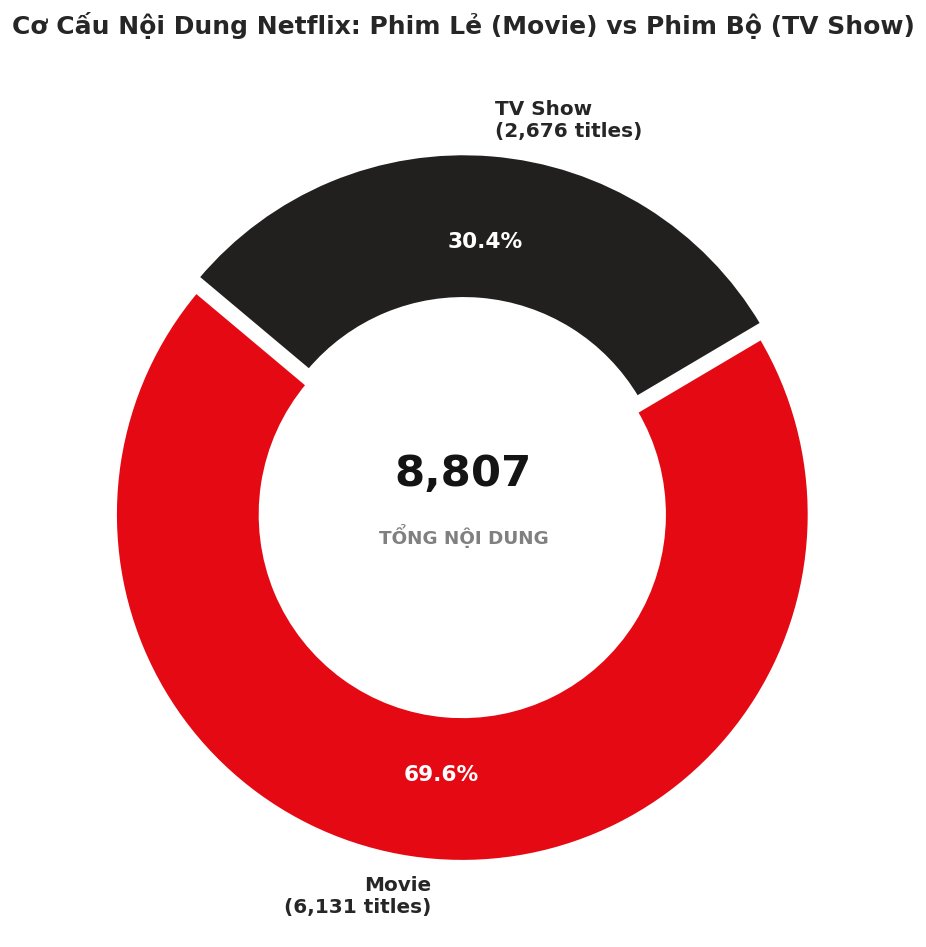

In [3]:
# Chart 1: Donut Chart - Movie vs TV Show
plt.figure(figsize=(8, 8))

type_counts = df['type'].value_counts()
colors = [NETFLIX_RED, NETFLIX_GRAY]
explode = (0.04, 0)

wedges, texts, autotexts = plt.pie(
    type_counts,
    labels=[f"{label}\n({count:,} titles)" for label, count in type_counts.items()],
    autopct='%1.1f%%',
    pctdistance=0.75,
    startangle=140,
    colors=colors,
    explode=explode,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2.5),
    textprops={'fontsize': 12, 'weight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_weight('bold')

plt.text(0, 0.08, f"{len(df):,}", ha='center', va='center', fontsize=26, weight='bold', color=NETFLIX_BLACK)
plt.text(0, -0.10, "TỔNG NỘI DUNG", ha='center', va='center', fontsize=11, weight='bold', color='gray')

plt.title('Cơ Cấu Nội Dung Netflix: Phim Lẻ (Movie) vs Phim Bộ (TV Show)', fontsize=15, pad=20)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 2: Horizontal Bar Chart — Top 10 Quốc Gia Sản Xuất Nhiều Nội Dung Nhất
- **Mục tiêu:** Xác định các thị trường cốt lõi và trung tâm sản xuất nội dung toàn cầu của Netflix.
- **Thấu cảm dữ liệu:** Hoa Kỳ áp đảo hoàn toàn với **3.211 tác phẩm (36.5%)**, theo sau là Ấn Độ với **1.008 tác phẩm (11.4%)**, Vương quốc Anh (628), Canada (271), Nhật Bản (259), Pháp (213) và Hàn Quốc (212).
- **Thiết kế trực quan:** Bar chart nằm ngang sắp xếp giảm dần, có nhãn giá trị và % cụ thể trên từng thanh bar.


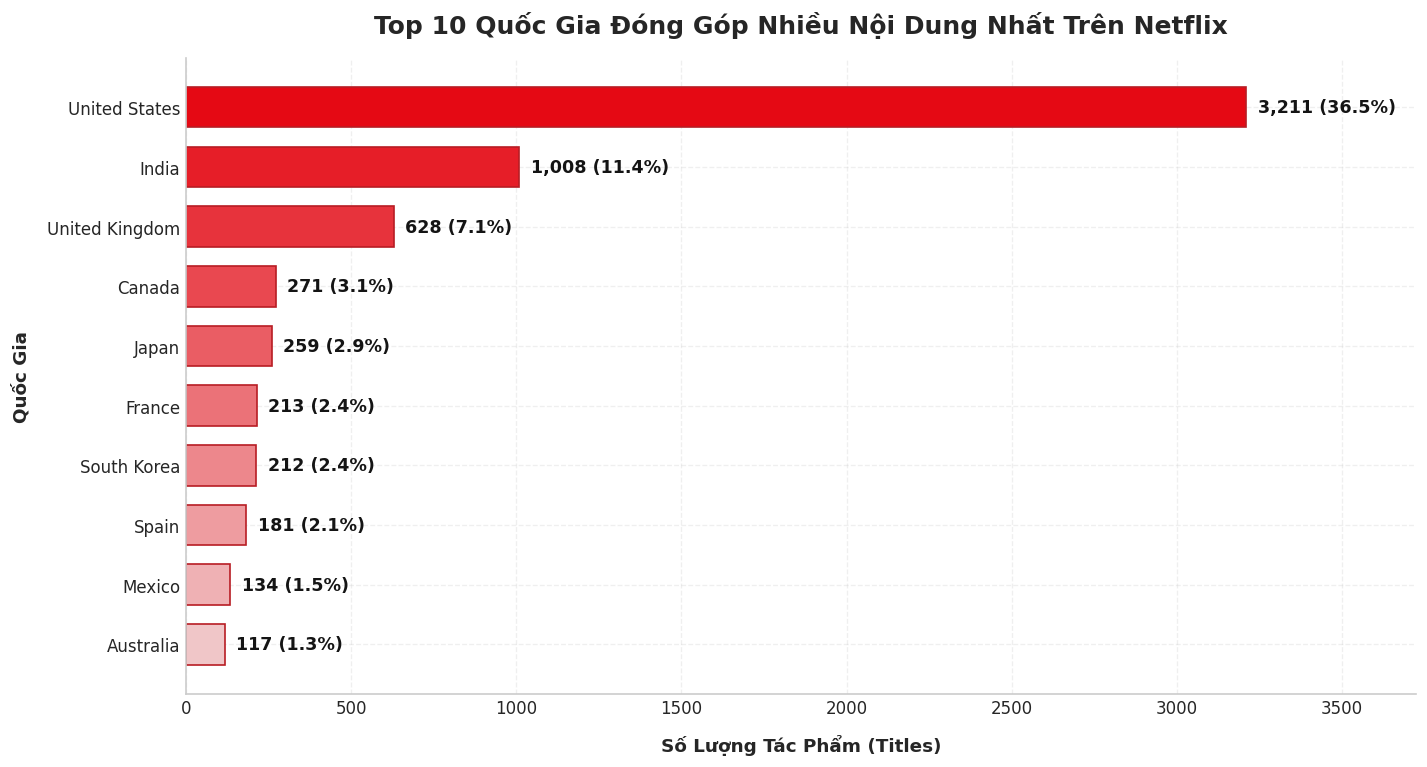

In [4]:
# Chart 2: Top 10 Quốc Gia Sản Xuất
plt.figure(figsize=(12, 6.5))

country_counts = df[~df['primary_country'].isin(['Unknown', '']) ]['primary_country'].value_counts().head(10)
country_counts = country_counts.sort_values(ascending=True)

colors_bar = [sns.light_palette(NETFLIX_RED, n_colors=12)[i] for i in range(2, 12)]
bars = plt.barh(country_counts.index, country_counts.values, color=colors_bar, edgecolor=NETFLIX_DARK_RED, linewidth=1, height=0.68)

total_titles = len(df)
for bar in bars:
    width = bar.get_width()
    pct = (width / total_titles) * 100
    plt.text(width + 35, bar.get_y() + bar.get_height()/2, f"{int(width):,} ({pct:.1f}%)",
             ha='left', va='center', fontsize=10.5, weight='bold', color=NETFLIX_BLACK)

plt.title('Top 10 Quốc Gia Đóng Góp Nhiều Nội Dung Nhất Trên Netflix', fontsize=15, pad=15)
plt.xlabel('Số Lượng Tác Phẩm (Titles)', labelpad=10)
plt.ylabel('Quốc Gia', labelpad=10)
plt.xlim(0, max(country_counts.values) * 1.16)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---
# 📅 NHÓM 2: XU HƯỚNG THEO THỜI GIAN (TIME TRENDS & SEASONALITY)
Nhóm biểu đồ theo dõi hành trình mở rộng danh mục nội dung của Netflix qua các năm, phát hiện bước ngoặt chiến lược và chu kỳ mùa vụ trong việc phát hành phim.


### 📊 Biểu đồ 3: Area Chart — Tốc Độ Tăng Trưởng Lượng Nội Dung Mới Theo Năm
- **Mục tiêu:** Đo lường quy mô bổ sung kho phim hàng năm từ 2008 đến 2021.
- **Thấu cảm dữ liệu:** Netflix tăng tốc bùng nổ từ 2015 (84 phim) chạm đỉnh lịch sử vào **năm 2019 với 2.016 phim**, trước khi chững lại nhẹ trong giai đoạn 2020-2021 do ảnh hưởng gián đoạn sản xuất bởi đại dịch COVID-19.
- **Thiết kế trực quan:** Biểu đồ miền (Area Chart) gradient đỏ với điểm đánh dấu (marker) và hộp ghi chú đỉnh cao phát hành 2019.


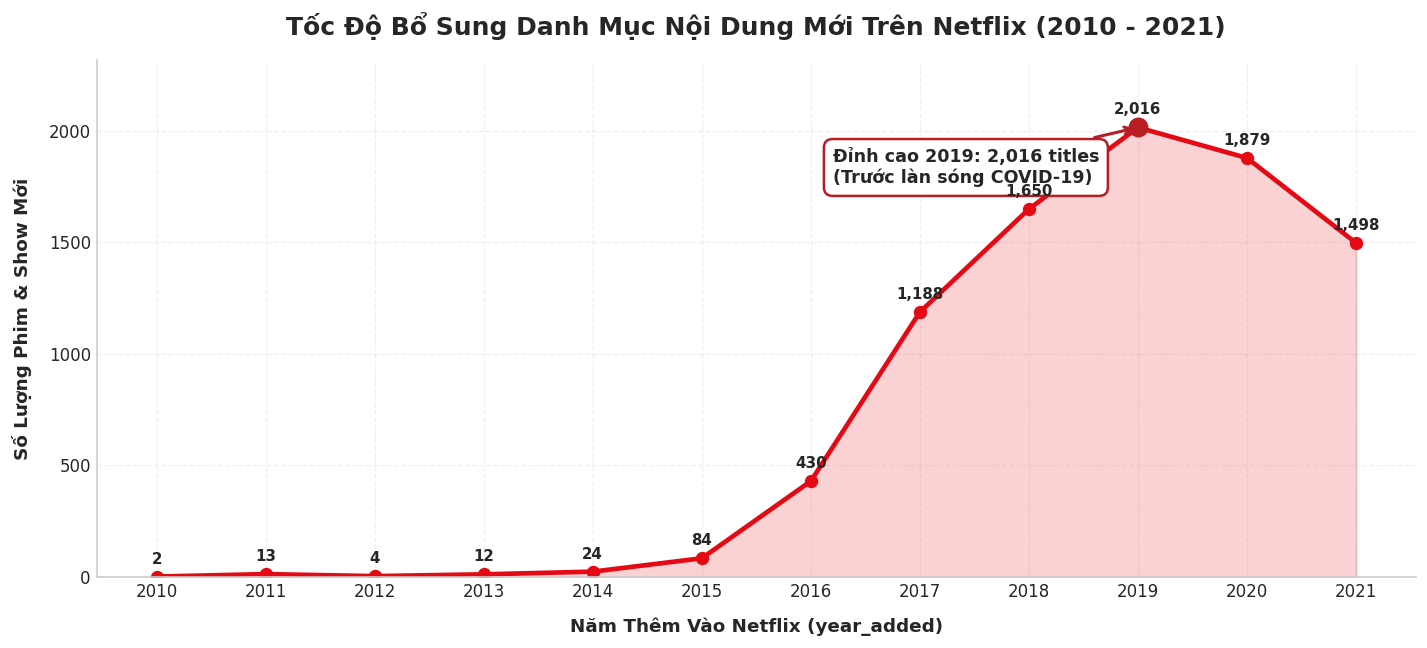

In [5]:
# Chart 3: Area Chart - Tăng trưởng theo năm (year_added)
plt.figure(figsize=(12, 5.5))

yearly_all = df[df['year_added'] >= 2010]['year_added'].value_counts().sort_index()

plt.plot(yearly_all.index, yearly_all.values, color=NETFLIX_RED, marker='o', markersize=7,
         linewidth=2.8, label='Tổng nội dung thêm mới')
plt.fill_between(yearly_all.index, yearly_all.values, color=NETFLIX_RED, alpha=0.18)

peak_year = 2019
peak_val = yearly_all[peak_year]
plt.scatter([peak_year], [peak_val], color=NETFLIX_DARK_RED, s=120, zorder=5)
plt.annotate(f'Đỉnh cao 2019: {peak_val:,} titles\n(Trước làn sóng COVID-19)',
             xy=(peak_year, peak_val), xytext=(peak_year - 2.8, peak_val - 250),
             arrowprops=dict(arrowstyle='->', color=NETFLIX_DARK_RED, lw=1.8),
             bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=NETFLIX_DARK_RED, lw=1.5),
             fontsize=10.5, weight='bold')

for x, y in zip(yearly_all.index, yearly_all.values):
    plt.text(x, y + 45, f"{y:,}", ha='center', va='bottom', fontsize=9, weight='bold')

plt.title('Tốc Độ Bổ Sung Danh Mục Nội Dung Mới Trên Netflix (2010 - 2021)', fontsize=15, pad=15)
plt.xlabel('Năm Thêm Vào Netflix (year_added)', labelpad=10)
plt.ylabel('Số Lượng Phim & Show Mới', labelpad=10)
plt.xticks(yearly_all.index)
plt.ylim(0, max(yearly_all.values) * 1.15)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 4: Grouped / Stacked Bar Chart — Cơ Cấu Bổ Sung Movie vs TV Show Qua Từng Năm
- **Mục tiêu:** So sánh sự dịch chuyển ưu tiên giữa Phim lẻ và Phim bộ theo từng mốc thời gian.
- **Thấu cảm dữ liệu:** Phim lẻ luôn chiếm tỷ trọng bổ sung áp đảo trong giai đoạn hoàng kim 2017-2019. Tuy nhiên, TV Shows duy trì tính ổn định cao hơn trong năm 2020 và 2021 nhằm tối ưu hóa chi phí và giữ chân người dùng đăng ký hàng tháng.
- **Thiết kế trực quan:** Biểu đồ cột ghép (Grouped Bar Chart) tương phản sắc nét giữa Netflix Red (Movie) và Classic Blue (TV Show).


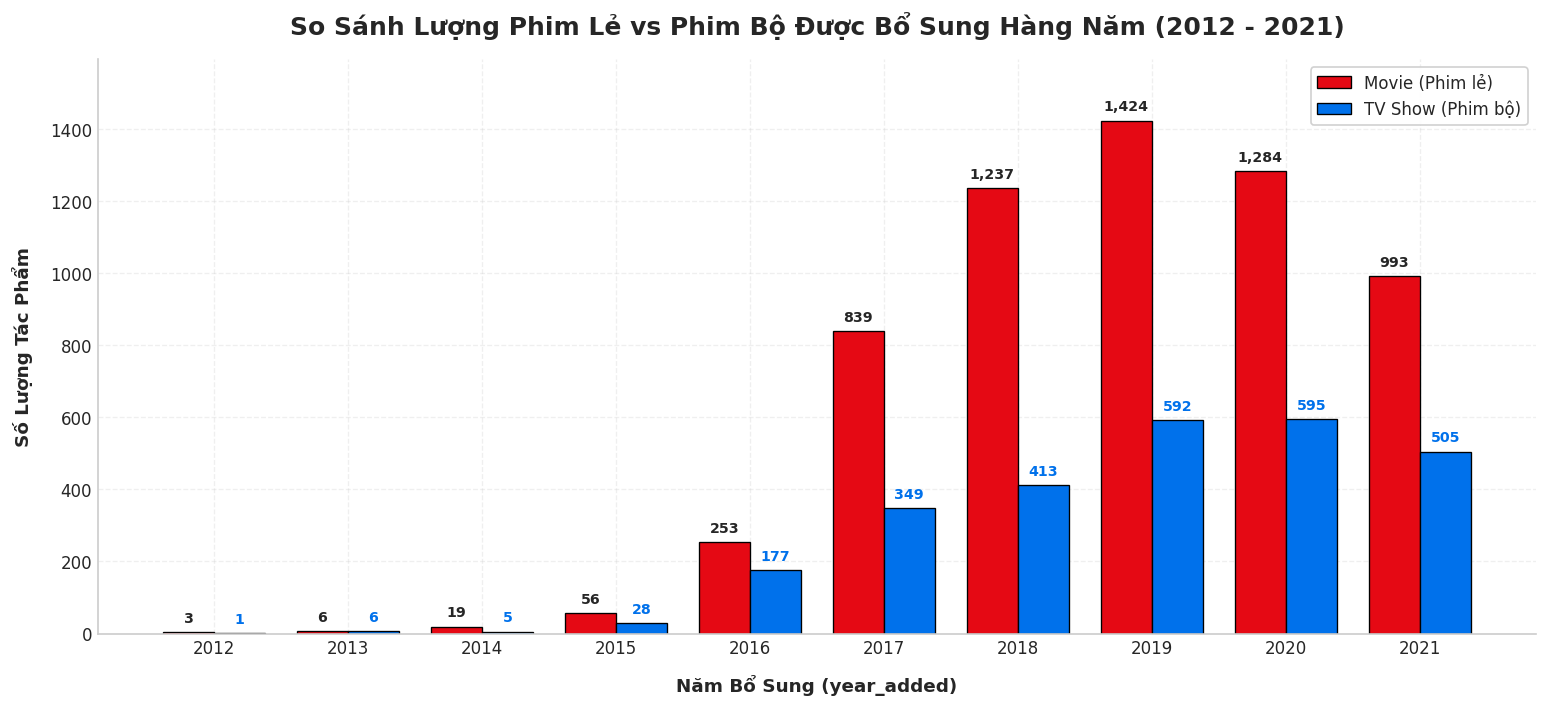

In [6]:
# Chart 4: Grouped Bar Chart - Movie vs TV Show theo năm
plt.figure(figsize=(13, 6))

yearly_type = df[df['year_added'] >= 2012].groupby(['year_added', 'type']).size().unstack(fill_value=0)

x = np.arange(len(yearly_type.index))
width = 0.38

bars1 = plt.bar(x - width/2, yearly_type['Movie'], width=width, label='Movie (Phim lẻ)',
                color=NETFLIX_RED, edgecolor='black', linewidth=0.8)
bars2 = plt.bar(x + width/2, yearly_type['TV Show'], width=width, label='TV Show (Phim bộ)',
                color=ACCENT_BLUE, edgecolor='black', linewidth=0.8)

for b in bars1:
    h = b.get_height()
    if h > 0:
        plt.text(b.get_x() + b.get_width()/2, h + 20, f"{int(h):,}", ha='center', va='bottom', fontsize=8.5, weight='bold')
for b in bars2:
    h = b.get_height()
    if h > 0:
        plt.text(b.get_x() + b.get_width()/2, h + 20, f"{int(h):,}", ha='center', va='bottom', fontsize=8.5, weight='bold', color=ACCENT_BLUE)

plt.title('So Sánh Lượng Phim Lẻ vs Phim Bộ Được Bổ Sung Hàng Năm (2012 - 2021)', fontsize=15, pad=15)
plt.xlabel('Năm Bổ Sung (year_added)', labelpad=10)
plt.ylabel('Số Lượng Tác Phẩm', labelpad=10)
plt.xticks(x, yearly_type.index)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.ylim(0, max(yearly_type['Movie'].max(), yearly_type['TV Show'].max()) * 1.12)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 5: Heatmap — Mật Độ Phát Hành Nội Dung Theo Tháng × Năm (Seasonal Heatmap)
- **Mục tiêu:** Nhận diện chiến lược chọn điểm rơi phát hành và ma trận mùa vụ của Netflix.
- **Thấu cảm dữ liệu:** Tháng 7 (kỳ nghỉ hè) và Tháng 12 (mùa Giáng sinh/Năm mới) ghi nhận các ô mật độ đậm nhất qua nhiều năm liên tiếp, phản ánh chiến lược đón đầu thời gian giải trí tại gia cao điểm của khán giả.
- **Thiết kế trực quan:** Heatmap 2D trực giao (Trục Y: Năm 2015-2021, Trục X: Tháng 1-12) với bảng màu gradient YlOrRd/Reds.


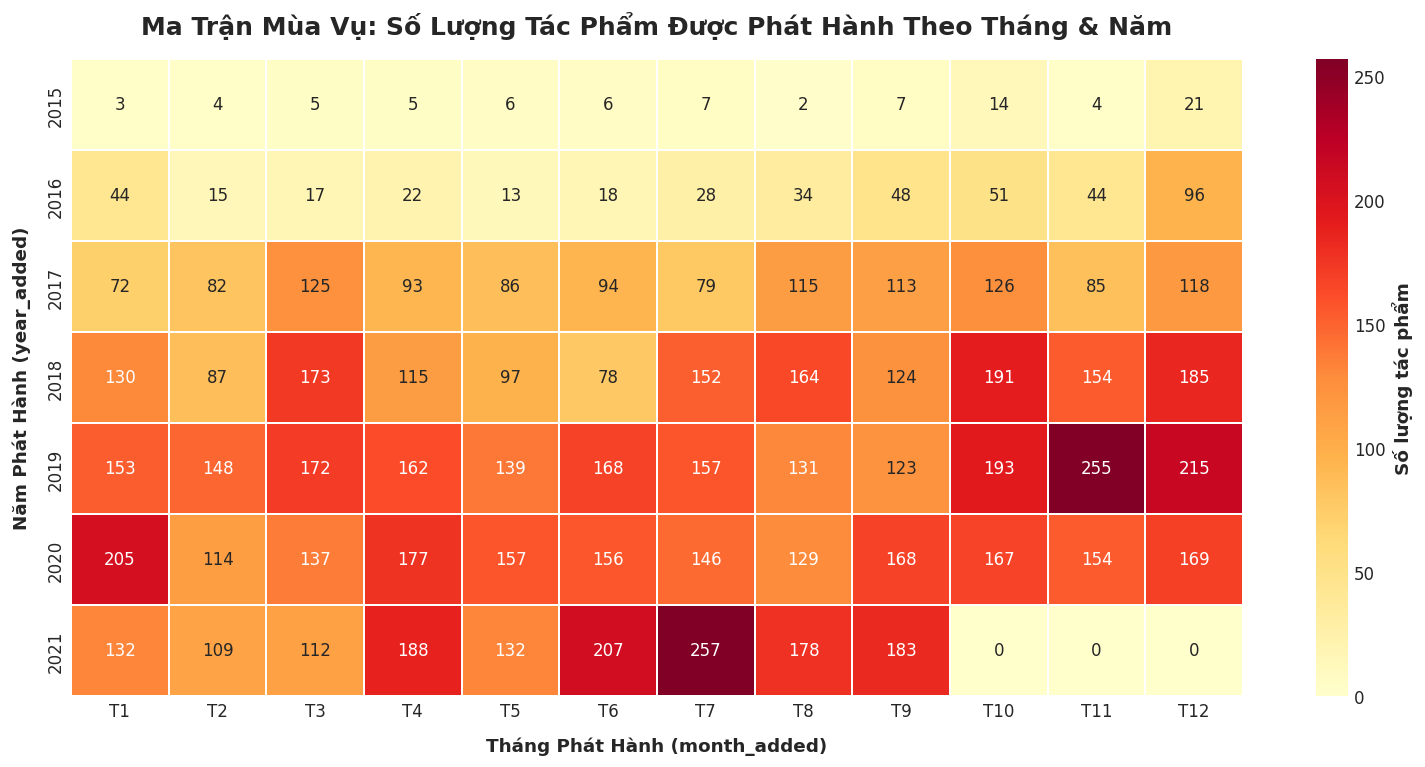

In [7]:
# Chart 5: Heatmap - Mật độ phát hành Tháng x Năm
plt.figure(figsize=(13, 6.5))

df_recent = df[(df['year_added'] >= 2015) & (df['year_added'] <= 2021)]
heatmap_data = df_recent.pivot_table(index='year_added', columns='month_added', values='show_id', aggfunc='count', fill_value=0)

month_names = ['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T10', 'T11', 'T12']
heatmap_data.columns = [month_names[i-1] for i in heatmap_data.columns]

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Số lượng tác phẩm'},
            linewidths=1.2, linecolor='white')

plt.title('Ma Trận Mùa Vụ: Số Lượng Tác Phẩm Được Phát Hành Theo Tháng & Năm', fontsize=15, pad=15)
plt.xlabel('Tháng Phát Hành (month_added)', labelpad=10)
plt.ylabel('Năm Phát Hành (year_added)', labelpad=10)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 6: Bar Chart — Phân Phối Tổng Lượng Nội Dung Theo 12 Tháng (All-time Seasonality)
- **Mục tiêu:** Đánh giá tính chu kỳ mùa vụ tổng thể trong kế hoạch ra mắt nội dung.
- **Thấu cảm dữ liệu:** Tháng 7 đạt đỉnh với **827 titles**, theo sát là Tháng 12 với **813 titles**. Tháng 2 ghi nhận mức thấp nhất với chỉ **563 titles** (ít hơn đỉnh 32%), một phần do số ngày ít hơn và tâm lý tái đầu tư sản xuất sau dịp Tết Dương lịch.
- **Thiết kế trực quan:** Bar chart nổi bật cột cực đại và cực tiểu, có đường tham chiếu trung bình hàng tháng (~734 titles).


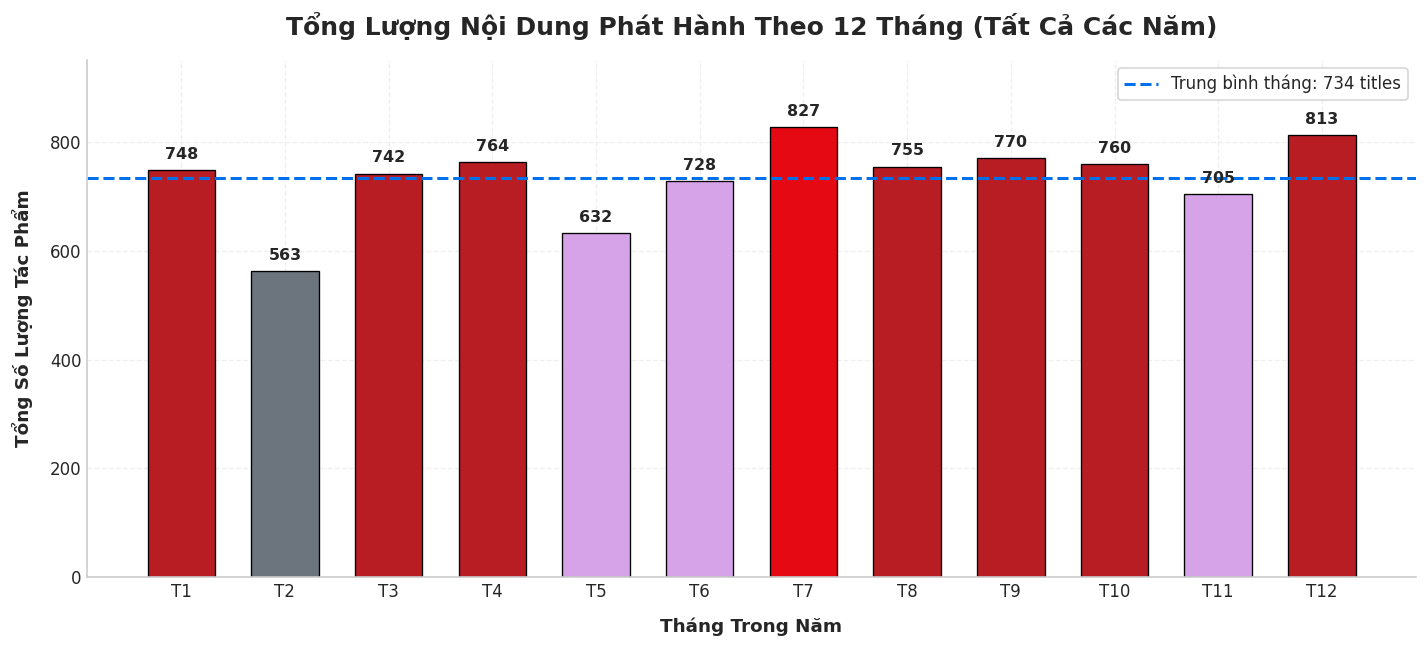

In [8]:
# Chart 6: Phân phối theo 12 tháng
plt.figure(figsize=(12, 5.5))

monthly_counts = df['month_added'].value_counts().sort_index()
avg_monthly = monthly_counts.mean()

colors_month = []
for m, val in monthly_counts.items():
    if val == monthly_counts.max():
        colors_month.append(NETFLIX_RED)
    elif val == monthly_counts.min():
        colors_month.append('#6C757D')
    elif val > avg_monthly:
        colors_month.append(NETFLIX_DARK_RED)
    else:
        colors_month.append('#D6A2E8')

bars = plt.bar([month_names[i-1] for i in monthly_counts.index], monthly_counts.values,
               color=colors_month, edgecolor='black', linewidth=0.8, width=0.65)

plt.axhline(avg_monthly, color=ACCENT_BLUE, linestyle='--', linewidth=1.8,
            label=f'Trung bình tháng: {avg_monthly:.0f} titles')

for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, h + 15, f"{int(h):,}", ha='center', va='bottom', fontsize=9.5, weight='bold')

plt.title('Tổng Lượng Nội Dung Phát Hành Theo 12 Tháng (Tất Cả Các Năm)', fontsize=15, pad=15)
plt.xlabel('Tháng Trong Năm', labelpad=10)
plt.ylabel('Tổng Số Lượng Tác Phẩm', labelpad=10)
plt.legend(frameon=True, facecolor='white')
plt.ylim(0, max(monthly_counts.values) * 1.15)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---
# 🎭 NHÓM 3: THỂ LOẠI & PHÂN LOẠI ĐỘ TUỔI (GENRE & RATING)
Phân tích thể loại và giới hạn độ tuổi cung cấp bức tranh chi tiết về đối tượng khán giả mục tiêu mà Netflix nhắm tới.


### 📊 Biểu đồ 7: Horizontal Bar Chart — Top 15 Thể Loại Phổ Biến Nhất Trên Netflix
- **Mục tiêu:** Khám phá danh mục thể loại chủ lực tạo nên thương hiệu Netflix.
- **Thấu cảm dữ liệu:** **Dramas (1.600)** và **Comedies (1.210)** chiếm giữ hai vị trí dẫn đầu tuyệt đối, tiếp theo là Action & Adventure (859) và Documentaries (829). Điểm đặc biệt: Stand-Up Comedy (334 tác phẩm) là một danh mục chuyên biệt phản ánh chiến lược đầu tư độc quyền mạnh mẽ của Netflix vào các danh hài nổi tiếng.
- **Thiết kế trực quan:** Bar chart nằm ngang được định dạng rõ ràng, phân cấp màu sắc theo thứ hạng.


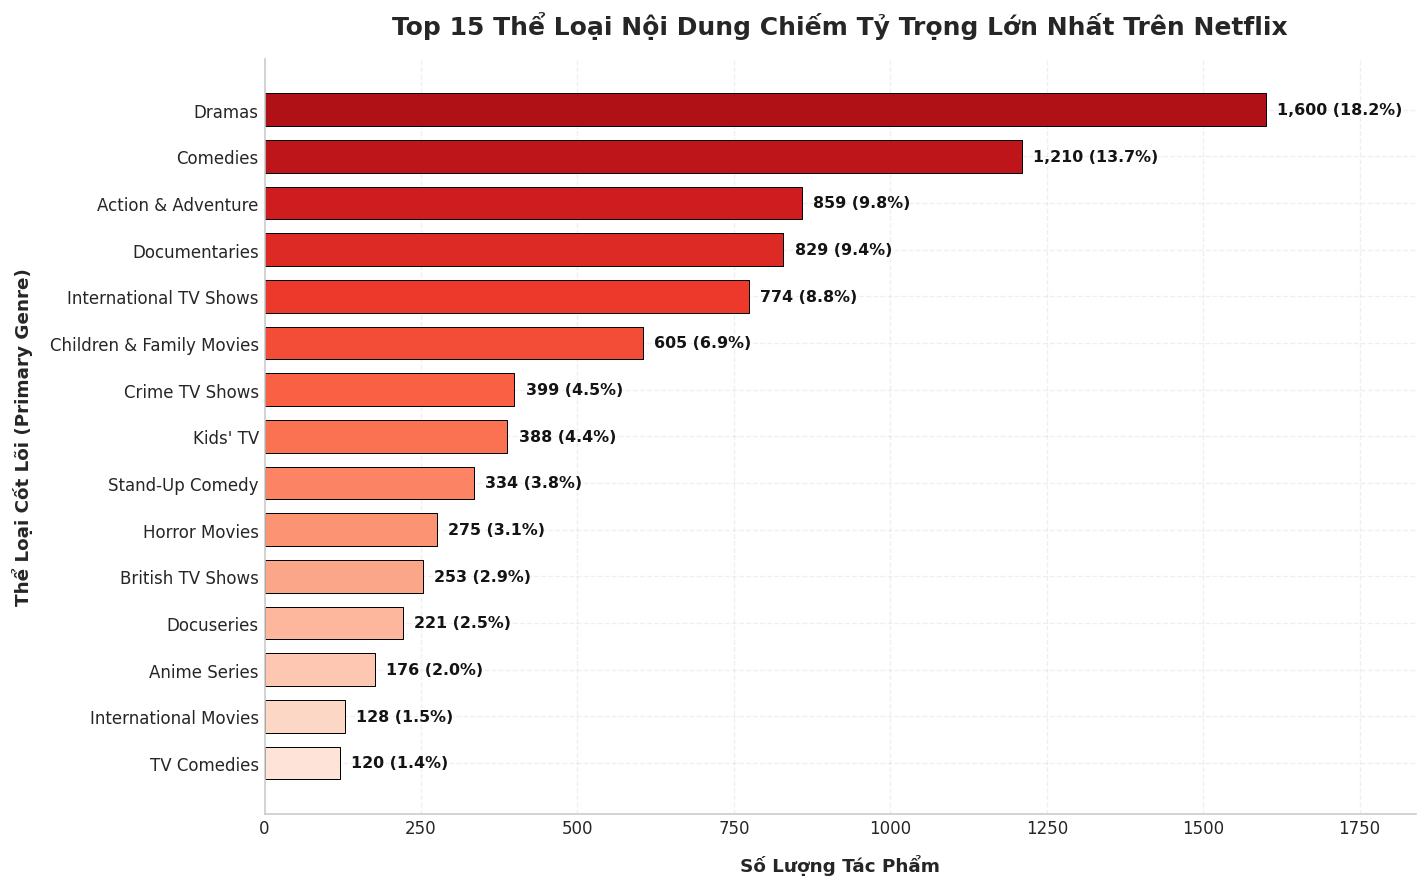

In [9]:
# Chart 7: Top 15 Thể loại phổ biến
plt.figure(figsize=(12, 7.5))

top_genres = df['primary_genre'].value_counts().head(15).sort_values(ascending=True)
palette = sns.color_palette("Reds_r", n_colors=18)[2:17][::-1]

bars = plt.barh(top_genres.index, top_genres.values, color=palette, edgecolor='black', linewidth=0.6, height=0.7)

for bar in bars:
    w = bar.get_width()
    pct = (w / len(df)) * 100
    plt.text(w + 18, bar.get_y() + bar.get_height()/2, f"{int(w):,} ({pct:.1f}%)",
             ha='left', va='center', fontsize=9.5, weight='bold', color=NETFLIX_BLACK)

plt.title('Top 15 Thể Loại Nội Dung Chiếm Tỷ Trọng Lớn Nhất Trên Netflix', fontsize=15, pad=15)
plt.xlabel('Số Lượng Tác Phẩm', labelpad=10)
plt.ylabel('Thể Loại Cốt Lõi (Primary Genre)', labelpad=10)
plt.xlim(0, max(top_genres.values) * 1.15)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 8: Bar Chart — Phân Phối Phân Loại Độ Tuổi (Rating Distribution)
- **Mục tiêu:** Đo lường tỷ trọng phân khúc khán giả theo lứa tuổi.
- **Thấu cảm dữ liệu:** Nội dung người lớn chiếm ưu thế vượt trội: **TV-MA (18+) chiếm 36.5% (3.211 titles)**, cộng với **TV-14 (14+) chiếm 24.5% (2.160 titles)** và R (799 titles). Tổng cộng hơn 61% nội dung yêu cầu người xem từ 14 tuổi trở lên. Nội dung dành cho thiếu nhi (TV-Y, TV-Y7, G) chiếm khoảng 10%.
- **Thiết kế trực quan:** Biểu đồ cột phân chia sắc thái theo từng nhóm đối tượng (Người lớn, Thanh thiếu niên, Gia đình, Trẻ em).


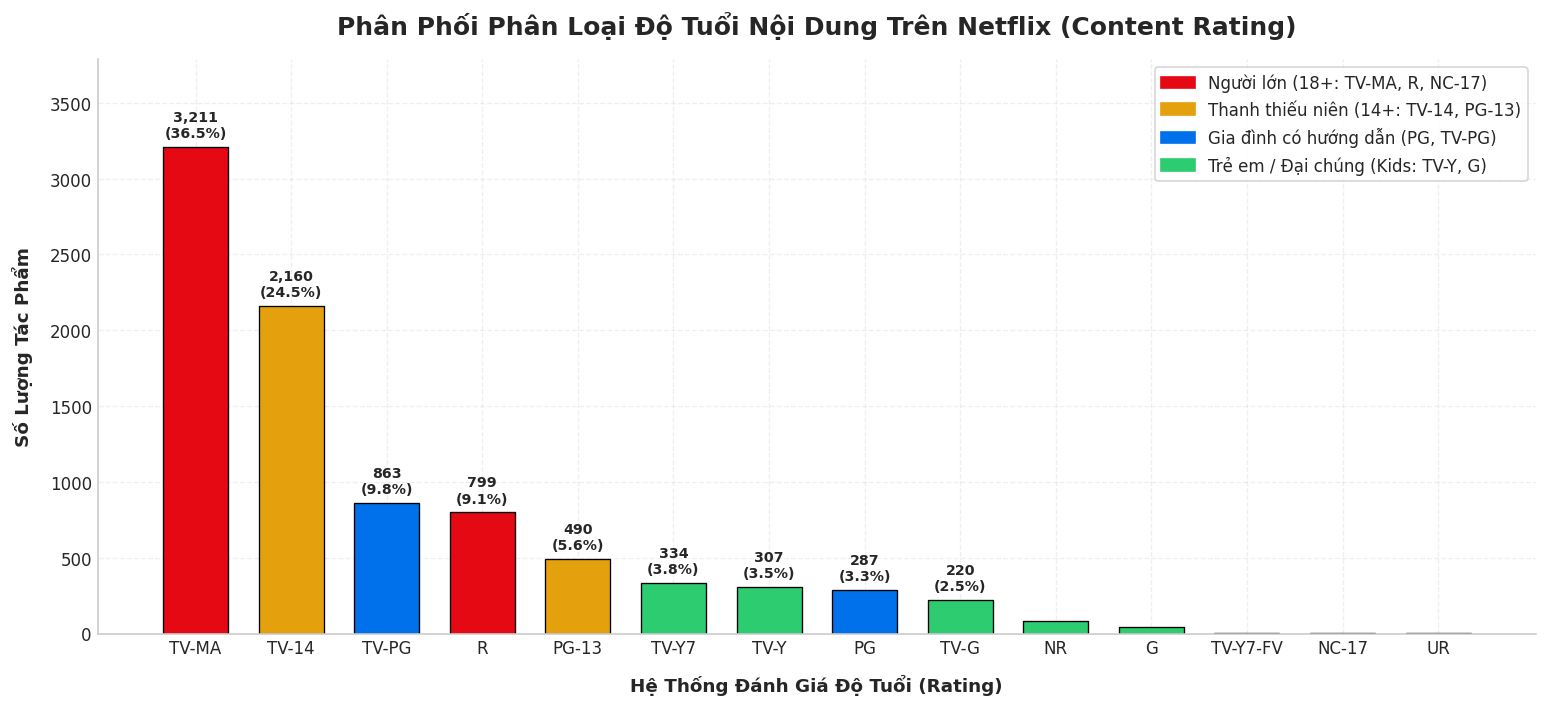

In [10]:
# Chart 8: Phân phối Rating
plt.figure(figsize=(13, 6))

rating_counts = df['rating'].value_counts()
adult_ratings = ['TV-MA', 'R', 'NC-17', 'UR']
teen_ratings = ['TV-14', 'PG-13']
family_ratings = ['TV-PG', 'PG']
kids_ratings = ['TV-Y', 'TV-Y7', 'TV-G', 'G', 'TV-Y7-FV']

rating_colors = []
for r in rating_counts.index:
    if r in adult_ratings:
        rating_colors.append(NETFLIX_RED)
    elif r in teen_ratings:
        rating_colors.append(ACCENT_GOLD)
    elif r in family_ratings:
        rating_colors.append(ACCENT_BLUE)
    else:
        rating_colors.append('#2ECC71')

bars = plt.bar(rating_counts.index, rating_counts.values, color=rating_colors,
               edgecolor='black', linewidth=0.8, width=0.68)

for bar in bars:
    h = bar.get_height()
    pct = (h / len(df)) * 100
    if h > 100:
        plt.text(bar.get_x() + bar.get_width()/2, h + 45, f"{int(h):,}\n({pct:.1f}%)",
                 ha='center', va='bottom', fontsize=8.5, weight='bold')

legend_elements = [
    plt.Rectangle((0,0),1,1, color=NETFLIX_RED, label='Người lớn (18+: TV-MA, R, NC-17)'),
    plt.Rectangle((0,0),1,1, color=ACCENT_GOLD, label='Thanh thiếu niên (14+: TV-14, PG-13)'),
    plt.Rectangle((0,0),1,1, color=ACCENT_BLUE, label='Gia đình có hướng dẫn (PG, TV-PG)'),
    plt.Rectangle((0,0),1,1, color='#2ECC71', label='Trẻ em / Đại chúng (Kids: TV-Y, G)')
]
plt.legend(handles=legend_elements, frameon=True, facecolor='white', loc='upper right')

plt.title('Phân Phối Phân Loại Độ Tuổi Nội Dung Trên Netflix (Content Rating)', fontsize=15, pad=15)
plt.xlabel('Hệ Thống Đánh Giá Độ Tuổi (Rating)', labelpad=10)
plt.ylabel('Số Lượng Tác Phẩm', labelpad=10)
plt.ylim(0, max(rating_counts.values) * 1.18)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 9: 100% Stacked Bar Chart — So Sánh Tỷ Trọng Rating Giữa Movie và TV Show
- **Mục tiêu:** Khám phá sự khác biệt trong chiến lược phân loại độ tuổi giữa Phim lẻ và Phim bộ.
- **Thấu cảm dữ liệu:** TV Show có tỷ lệ gắn nhãn TV-MA (18+) cao hơn đáng kể (lên đến ~43%) so với Movie, đồng thời các series truyền hình tập trung cao độ vào hai mã TV-MA và TV-14. Trong khi đó, Movie phân bổ đa dạng hơn trên hệ thống chuẩn điện ảnh (R, PG-13, PG, G).
- **Thiết kế trực quan:** Biểu đồ cột chồng 100% chuẩn hóa, so sánh trực diện tỷ trọng phân khúc của từng loại hình.


<Figure size 1200x780 with 0 Axes>

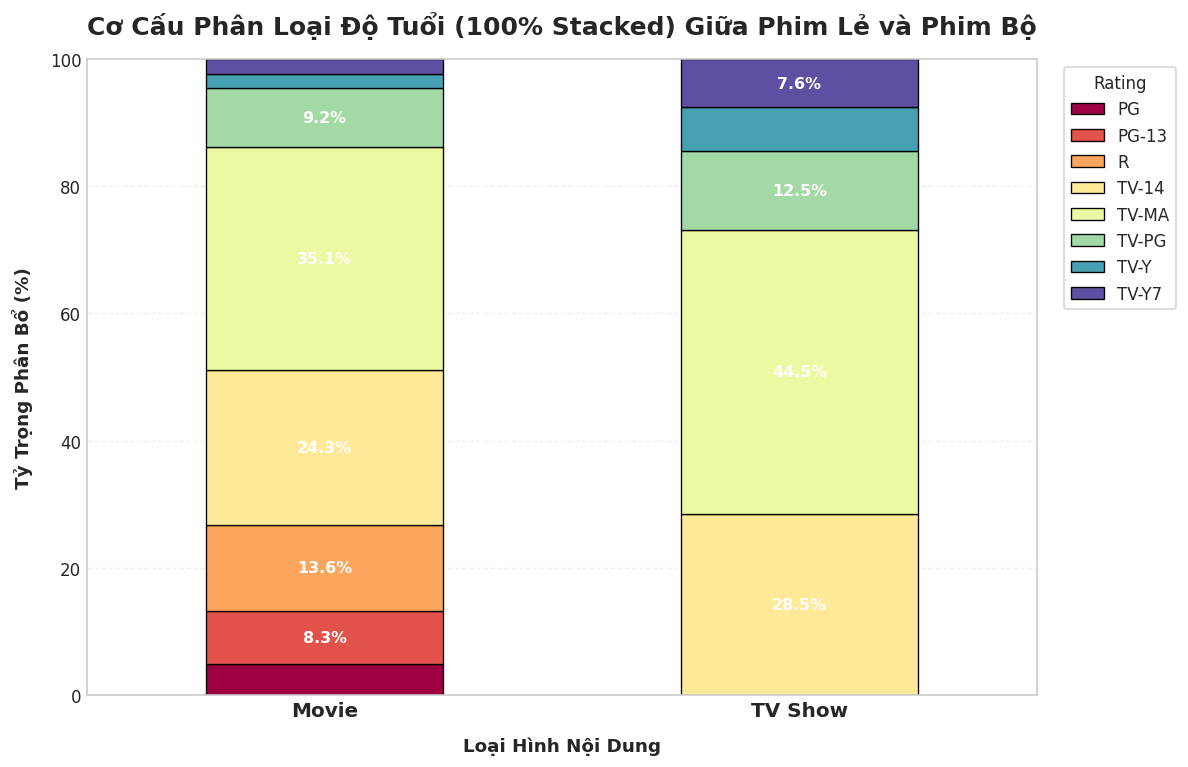

In [11]:
# Chart 9: 100% Stacked Bar - Rating theo Movie vs TV Show
plt.figure(figsize=(10, 6.5))

top_8_ratings = df['rating'].value_counts().head(8).index
df_rating_type = df[df['rating'].isin(top_8_ratings)]
ct = pd.crosstab(df_rating_type['type'], df_rating_type['rating'], normalize='index') * 100

ax = ct.plot(kind='bar', stacked=True, colormap='Spectral', edgecolor='black', linewidth=0.8, figsize=(10, 6.5))

plt.title('Cơ Cấu Phân Loại Độ Tuổi (100% Stacked) Giữa Phim Lẻ và Phim Bộ', fontsize=15, pad=15)
plt.xlabel('Loại Hình Nội Dung', labelpad=10)
plt.ylabel('Tỷ Trọng Phân Bổ (%)', labelpad=10)
plt.xticks(rotation=0, fontsize=12, weight='bold')
plt.legend(title='Rating', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.ylim(0, 100)

for c in ax.containers:
    for bar in c:
        height = bar.get_height()
        if height > 7.0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + height/2, f"{height:.1f}%",
                    ha='center', va='center', color='white', weight='bold', fontsize=9.5)

plt.tight_layout()
plt.show()


---
# ⏱️ NHÓM 4: THỜI LƯỢNG & SỐ MÙA PHÁT SÓNG (DURATION & SEASONS)
Phân tích định lượng về chiều dài của tác phẩm: Thời lượng phim lẻ (phút) và vòng đời của các series truyền hình (số seasons).


### 📊 Biểu đồ 10: Histogram & KDE — Phân Phối Thời Lượng Phim Lẻ (Movies in Minutes)
- **Mục tiêu:** Xác định chuẩn mực thời lượng phim phổ biến nhất của các tác phẩm điện ảnh trên Netflix.
- **Thấu cảm dữ liệu:** Thời lượng trung bình là **99.6 phút (~100 phút)**, với phân phối hình chuông lệch phải nhẹ. Hơn 75% phim nằm trong khoảng "vàng" từ **80 đến 120 phút**. Có những phim ngắn chỉ 3-20 phút (phim ngắn hoạt hình) và phim trường ca kéo dài tới hơn 300 phút.
- **Thiết kế trực quan:** Histogram 30 bins kết hợp đường cong mật độ KDE và đường tham chiếu giá trị trung bình/trung vị.


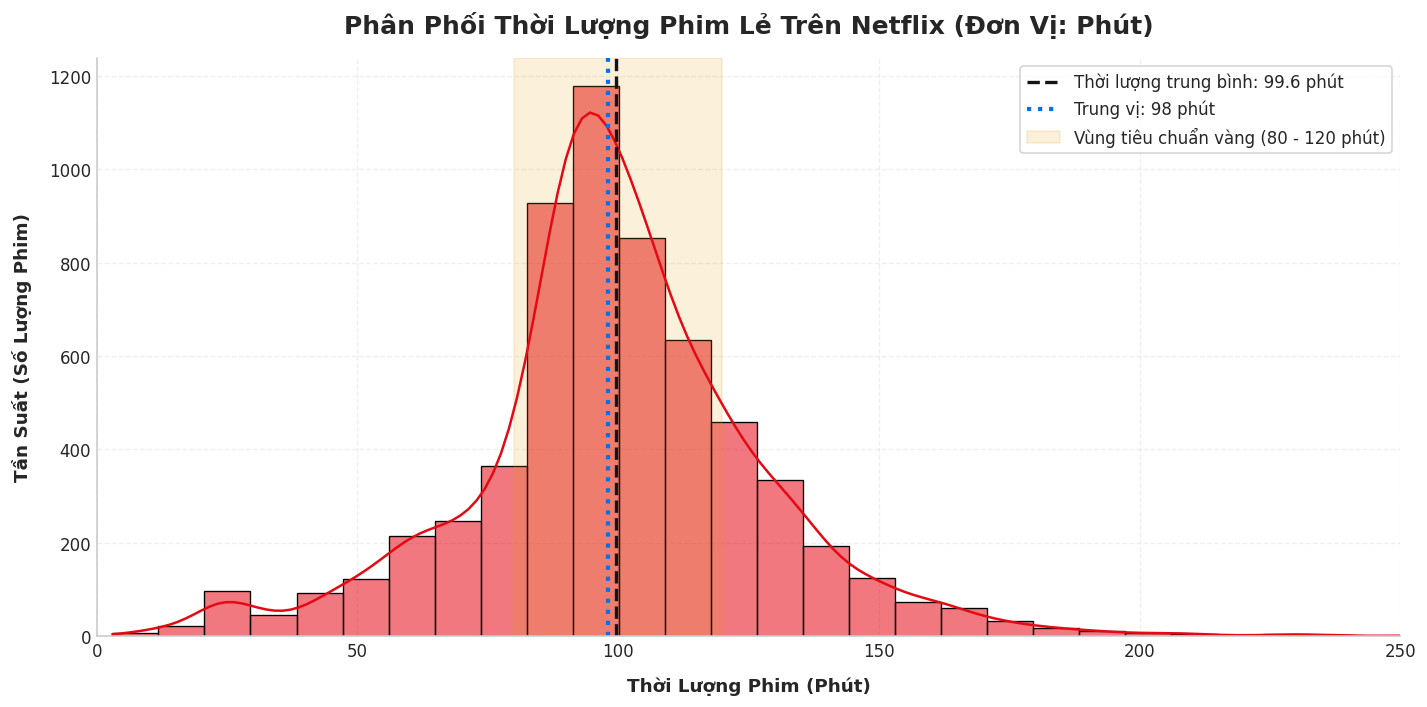

In [12]:
# Chart 10: Histogram & KDE Thời lượng phim lẻ
plt.figure(figsize=(12, 6))

movies_duration = df[(df['type'] == 'Movie') & (df['duration_unit'] == 'min')]['duration_int']

mean_dur = movies_duration.mean()
median_dur = movies_duration.median()

sns.histplot(movies_duration, bins=35, kde=True, color=NETFLIX_RED, edgecolor='black', linewidth=0.8, alpha=0.55)

plt.axvline(mean_dur, color=NETFLIX_BLACK, linestyle='--', linewidth=2,
            label=f'Thời lượng trung bình: {mean_dur:.1f} phút')
plt.axvline(median_dur, color=ACCENT_BLUE, linestyle=':', linewidth=2.5,
            label=f'Trung vị: {median_dur:.0f} phút')

plt.axvspan(80, 120, color=ACCENT_GOLD, alpha=0.15, label='Vùng tiêu chuẩn vàng (80 - 120 phút)')

plt.title('Phân Phối Thời Lượng Phim Lẻ Trên Netflix (Đơn Vị: Phút)', fontsize=15, pad=15)
plt.xlabel('Thời Lượng Phim (Phút)', labelpad=10)
plt.ylabel('Tần Suất (Số Lượng Phim)', labelpad=10)
plt.xlim(0, 250)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 11: Bar Chart — Phân Phối Số Mùa Của Các Series Truyền Hình (TV Show Seasons)
- **Mục tiêu:** Đo lường vòng đời và mức độ kéo dài của các bộ phim dài tập.
- **Thấu cảm dữ liệu:** Một phát hiện kinh ngạc: **67.0% TV Shows (1.793 series)** chỉ dừng lại ở đúng **1 Mùa (Season 1)**. Tỷ lệ này giảm dốc đứng: 2 Mùa còn 15.9% (425 show), 3 Mùa còn 7.4% (199 show). Chỉ một số ít thương hiệu siêu phẩm vượt mốc 5 mùa (như The Great British Baking Show, Grey's Anatomy).
- **Thiết kế trực quan:** Bar chart nổi bật tỷ lệ rụng rơi (drop-off rate) sau mùa đầu tiên, có số lượng và % chính xác trên đầu mỗi cột.


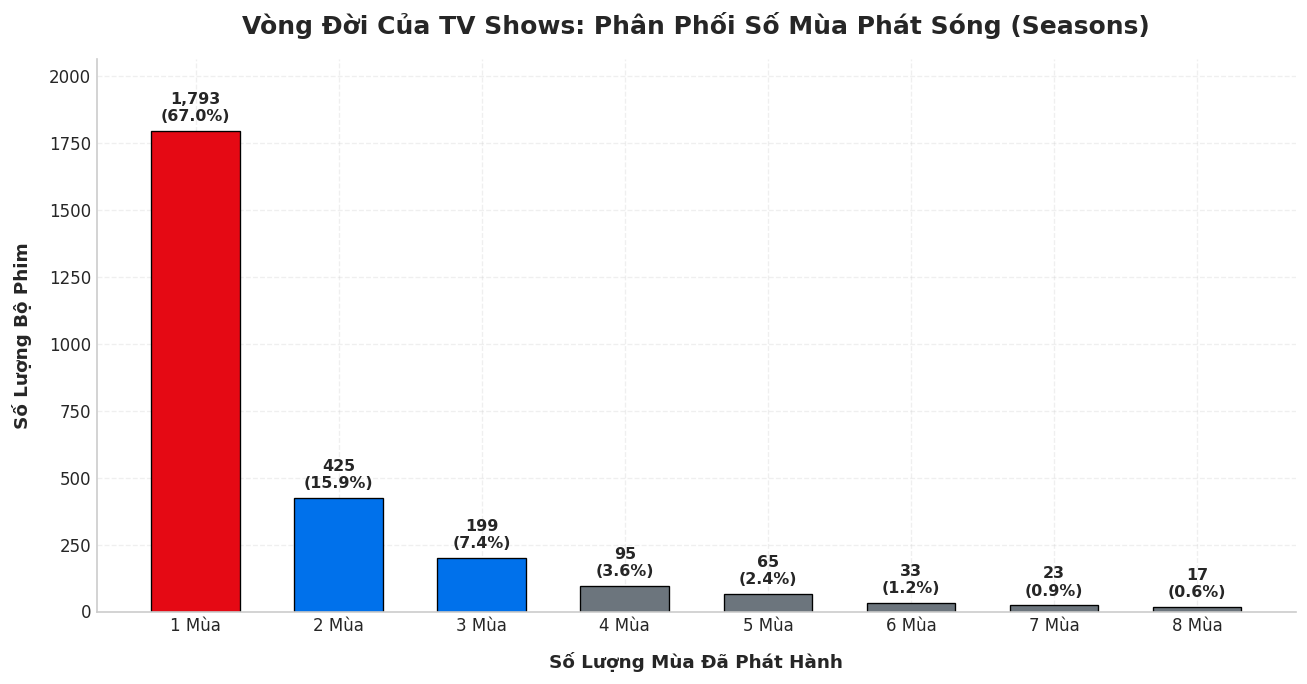

In [13]:
# Chart 11: Phân phối số mùa TV Show
plt.figure(figsize=(11, 5.8))

tv_seasons = df[df['type'] == 'TV Show']['duration_int'].value_counts().sort_index().head(8)
total_tv = len(df[df['type'] == 'TV Show'])

colors_seasons = [NETFLIX_RED if s == 1 else ACCENT_BLUE if s <= 3 else '#6C757D' for s in tv_seasons.index]

bars = plt.bar([f"{s} Mùa" for s in tv_seasons.index], tv_seasons.values,
               color=colors_seasons, edgecolor='black', linewidth=0.8, width=0.62)

for bar in bars:
    h = bar.get_height()
    pct = (h / total_tv) * 100
    plt.text(bar.get_x() + bar.get_width()/2, h + 25, f"{int(h):,}\n({pct:.1f}%)",
             ha='center', va='bottom', fontsize=9.5, weight='bold')

plt.title('Vòng Đời Của TV Shows: Phân Phối Số Mùa Phát Sóng (Seasons)', fontsize=15, pad=15)
plt.xlabel('Số Lượng Mùa Đã Phát Hành', labelpad=10)
plt.ylabel('Số Lượng Bộ Phim', labelpad=10)
plt.ylim(0, max(tv_seasons.values) * 1.15)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---
# 🌍 NHÓM 5: PHÂN TÍCH ĐỊA LÝ & NĂM SẢN XUẤT (GEOGRAPHY & RELEASE YEAR)
Xem xét nguồn gốc xuất xứ của nội dung trên bản đồ thế giới và khám phá kho tàng phim cổ điển đến hiện đại (1925 - 2021).


### 📊 Biểu đồ 12: Choropleth Map — Bản Đồ Phân Bố Toàn Cầu Của Nội Dung Netflix
- **Mục tiêu:** Trực quan hóa mức độ phủ sóng quốc tế của thư viện Netflix trên bản đồ thế giới.
- **Thấu cảm dữ liệu:** Bắc Mỹ (Mỹ, Canada), Nam Á (Ấn Độ), Tây Âu (Anh, Pháp, Tây Ban Nha) và Đông Á (Nhật Bản, Hàn Quốc) là những trung tâm sản xuất nội dung dồi dào nhất. Trong khi đó, khu vực Châu Phi và Trung Á còn nhiều tiềm năng khai phá nội dung bản địa.
- **Thiết kế trực quan:** Bản đồ Choropleth tương tác qua Plotly với tông màu Netflix Reds.


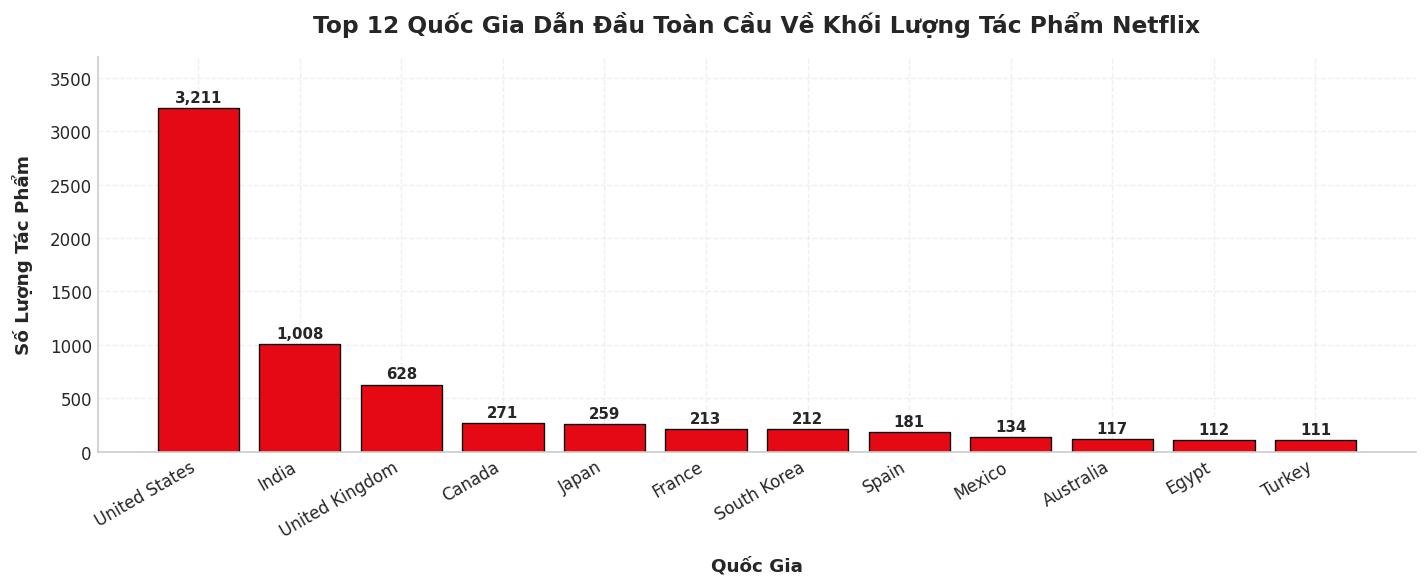

In [14]:
# Chart 12: Choropleth Map toàn cầu
country_data = df[~df['primary_country'].isin(['Unknown', ''])]['primary_country'].value_counts().reset_index()
country_data.columns = ['country', 'count']

if HAS_PLOTLY:
    fig = px.choropleth(
        country_data,
        locations='country',
        locationmode='country names',
        color='count',
        hover_name='country',
        hover_data={'count': ':,', 'country': False},
        color_continuous_scale='Reds',
        title='Bản Đồ Phân Bố Toàn Cầu: Số Lượng Tác Phẩm Netflix Theo Quốc Gia',
        labels={'count': 'Số tác phẩm'}
    )
    fig.update_layout(
        geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
        margin=dict(l=0, r=0, t=50, b=0),
        coloraxis_colorbar=dict(title="Số tác phẩm")
    )
    fig.show()

# Biểu đồ cột hỗ trợ xem tĩnh và xuất bản
plt.figure(figsize=(12, 5))
top_c = country_data.head(12)
plt.bar(top_c['country'], top_c['count'], color=NETFLIX_RED, edgecolor='black', linewidth=0.8)
for i, v in enumerate(top_c['count']):
    plt.text(i, v + 30, f"{v:,}", ha='center', va='bottom', fontsize=9, weight='bold')
plt.title('Top 12 Quốc Gia Dẫn Đầu Toàn Cầu Về Khối Lượng Tác Phẩm Netflix', fontsize=14, pad=15)
plt.xlabel('Quốc Gia', labelpad=10)
plt.ylabel('Số Lượng Tác Phẩm', labelpad=10)
plt.xticks(rotation=30, ha='right')
plt.ylim(0, max(top_c['count']) * 1.15)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 13: Area / Line Chart — Phân Phối Năm Sản Xuất Gốc (Release Year Distribution)
- **Mục tiêu:** Đánh giá độ mới và giá trị lưu trữ của các tác phẩm kinh điển trên Netflix.
- **Thấu cảm dữ liệu:** Tác phẩm lâu đời nhất phát hành từ **năm 1925**. Mặc dù lưu giữ nhiều di sản điện ảnh thế kỷ 20, hơn 85% danh mục của Netflix là những tác phẩm được sản xuất từ sau năm 2010, phù hợp với thị hiếu ưa chuộng chất lượng hình ảnh 4K/HDR hiện đại của người đăng ký.
- **Thiết kế trực quan:** Biểu đồ đường & diện tích thể hiện làn sóng phát hành phim gốc từ 1970 đến 2021.


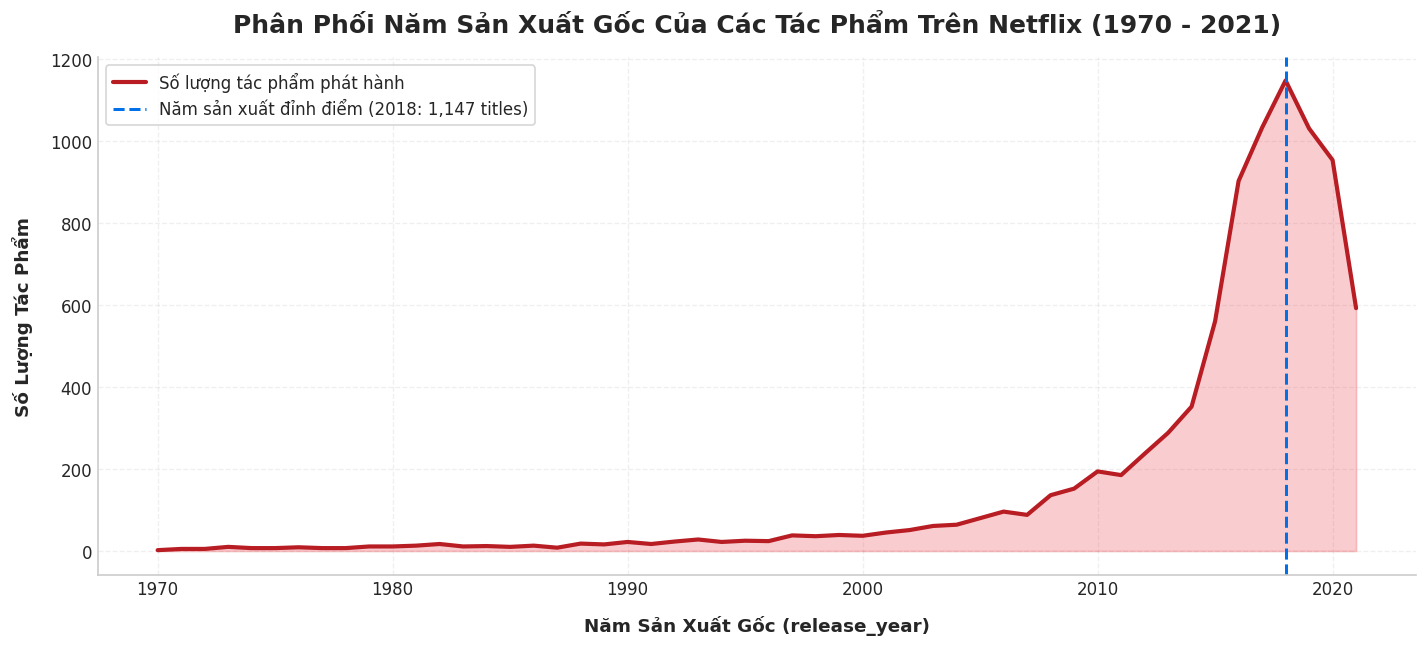

In [15]:
# Chart 13: Phân phối năm sản xuất gốc (release_year)
plt.figure(figsize=(12, 5.5))

release_counts = df[df['release_year'] >= 1970]['release_year'].value_counts().sort_index()

plt.plot(release_counts.index, release_counts.values, color=NETFLIX_DARK_RED, linewidth=2.5, label='Số lượng tác phẩm phát hành')
plt.fill_between(release_counts.index, release_counts.values, color=NETFLIX_RED, alpha=0.2)

plt.axvline(2018, color=ACCENT_BLUE, linestyle='--', linewidth=1.8, label='Năm sản xuất đỉnh điểm (2018: 1,147 titles)')

plt.title('Phân Phối Năm Sản Xuất Gốc Của Các Tác Phẩm Trên Netflix (1970 - 2021)', fontsize=15, pad=15)
plt.xlabel('Năm Sản Xuất Gốc (release_year)', labelpad=10)
plt.ylabel('Số Lượng Tác Phẩm', labelpad=10)
plt.legend(frameon=True, facecolor='white')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---
# 👥 NHÓM 6: DIỄN VIÊN & ĐẠO DIỄN (CAST & DIRECTORS)
Khám phá những đạo diễn có nhiều tác phẩm nhất trên nền tảng và tương quan quy mô dàn diễn viên (`cast_count`) giữa các thể loại điện ảnh.


### 📊 Biểu đồ 14: Horizontal Bar Chart — Top 10 Đạo Diễn Có Nhiều Tác Phẩm Nhất
- **Mục tiêu:** Tôn vinh các đạo diễn đóng góp nhiều nội dung nhất cho thư viện Netflix.
- **Thấu cảm dữ liệu:** **Rajiv Chilaka (19 tác phẩm)** dẫn đầu với loạt phim hoạt hình gia đình nổi tiếng tại Ấn Độ (Chhota Bheem). Theo sau là bộ đôi đạo diễn hài kịch Raúl Campos & Jan Suter (18 tác phẩm), Suhas Kadav (16), Marcus Raboy (16). Đáng chú ý, các huyền thoại Hollywood như **Martin Scorsese (12 tác phẩm)** và **Steven Spielberg (11 tác phẩm)** đều có mặt trong top 10.
- **Thiết kế trực quan:** Bar chart nằm ngang kèm nhãn số lượng tác phẩm cụ thể.


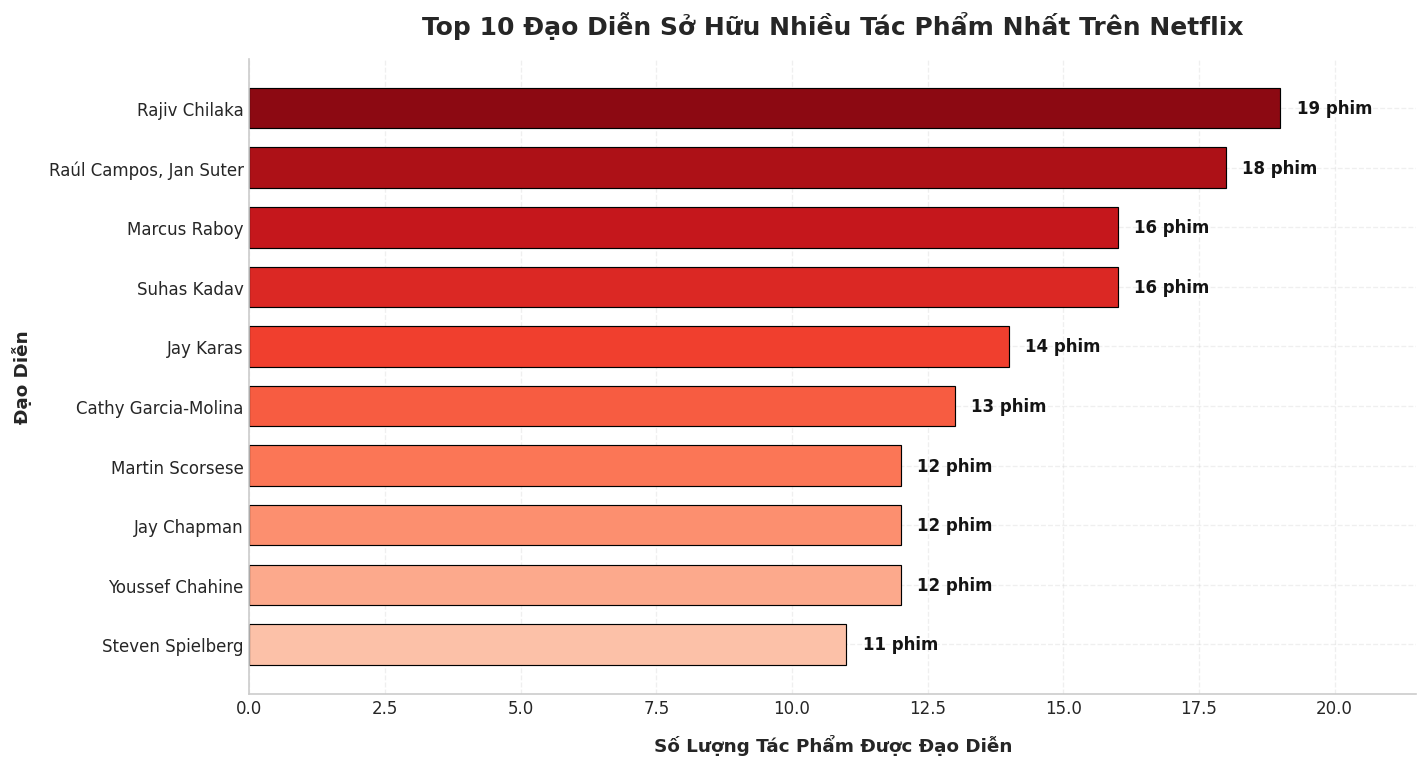

In [16]:
# Chart 14: Top 10 Đạo diễn
plt.figure(figsize=(12, 6.5))

top_directors = df[~df['director'].isin(['Unknown', '']) ]['director'].value_counts().head(10).sort_values(ascending=True)

bars = plt.barh(top_directors.index, top_directors.values, color=sns.color_palette("Reds", n_colors=12)[2:],
                edgecolor='black', linewidth=0.7, height=0.68)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.3, bar.get_y() + bar.get_height()/2, f"{int(w)} phim",
             ha='left', va='center', fontsize=10, weight='bold', color=NETFLIX_BLACK)

plt.title('Top 10 Đạo Diễn Sở Hữu Nhiều Tác Phẩm Nhất Trên Netflix', fontsize=15, pad=15)
plt.xlabel('Số Lượng Tác Phẩm Được Đạo Diễn', labelpad=10)
plt.ylabel('Đạo Diễn', labelpad=10)
plt.xlim(0, max(top_directors.values) + 2.5)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 15: Box Plot — Phân Phối Số Lượng Diễn Viên (cast_count) Theo Top Thể Loại
- **Mục tiêu:** Khảo sát quy mô nhân lực diễn viên tham gia trong từng nhóm thể loại nội dung.
- **Thấu cảm dữ liệu:** Trung bình một tác phẩm có **7.3 diễn viên** (tối đa lên tới 50 diễn viên). Các thể loại như **Dramas, Comedies, Action & Adventure** có trung vị từ 8-10 diễn viên. Trái lại, **Stand-Up Comedy** và **Documentaries** có dàn cast tinh gọn (trung vị chỉ 0-1 người), làm nổi bật bản chất biểu diễn độc thoại hoặc tài liệu thực tế.
- **Thiết kế trực quan:** Box Plot so sánh trung vị, khoảng tứ phân vị (IQR) và các giá trị ngoại lai (outliers) giữa 8 thể loại tiêu biểu.


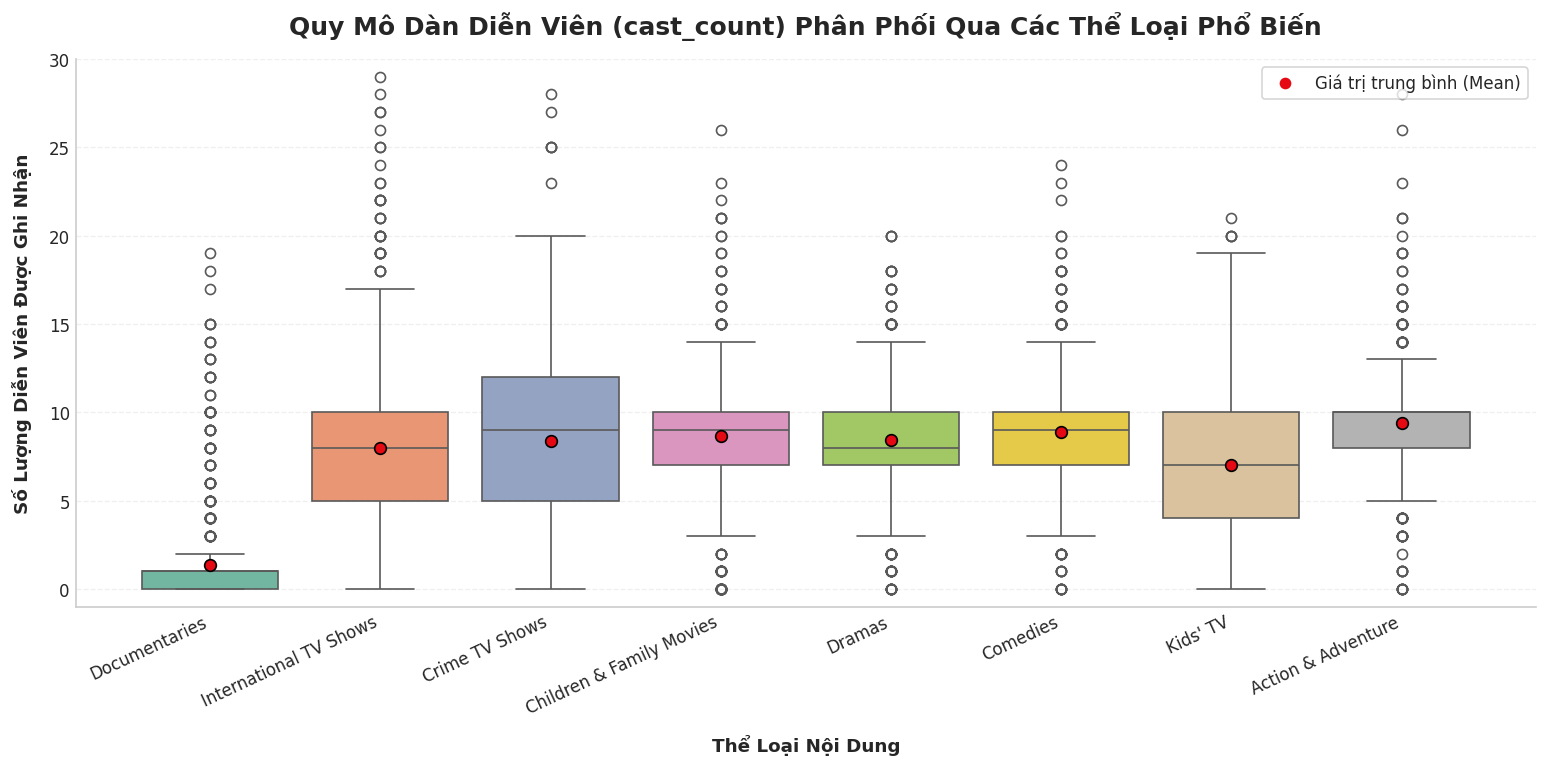

In [17]:
# Chart 15: Boxplot Số lượng diễn viên theo thể loại
plt.figure(figsize=(13, 6.5))

top_8_genres = df['primary_genre'].value_counts().head(8).index
df_box = df[df['primary_genre'].isin(top_8_genres)]

sns.boxplot(data=df_box, x='primary_genre', y='cast_count', palette='Set2', showmeans=True,
            meanprops={"marker":"o", "markerfacecolor":NETFLIX_RED, "markeredgecolor":"black", "markersize":"7"})

plt.title('Quy Mô Dàn Diễn Viên (cast_count) Phân Phối Qua Các Thể Loại Phổ Biến', fontsize=15, pad=15)
plt.xlabel('Thể Loại Nội Dung', labelpad=10)
plt.ylabel('Số Lượng Diễn Viên Được Ghi Nhận', labelpad=10)
plt.xticks(rotation=25, ha='right')
plt.ylim(-1, 30)

plt.plot([], [], marker='o', color=NETFLIX_RED, linestyle='None', label='Giá trị trung bình (Mean)')
plt.legend(loc='upper right', frameon=True, facecolor='white')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


---
# 🔗 NHÓM 7: PHÂN TÍCH NÂNG CAO & KHAI PHÁ VĂN BẢN (ADVANCED ANALYTICS & NLP)
Kết hợp phân tích tương quan nhiều chiều, phân tầng hệ sinh thái nội dung qua Treemap và khai phá từ khóa cốt truyện bằng Word Cloud.


### 📊 Biểu đồ 16: Scatter Plot — Mối Tương Quan Giữa Năm Sản Xuất và Thời Lượng Phim Lẻ
- **Mục tiêu:** Kiểm tra giả thuyết: Liệu phim ảnh thời xưa có dài hơn phim ảnh hiện đại hay không?
- **Thấu cảm dữ liệu:** Trong các thập niên 1960-1990, thời lượng phim có độ biến động rất cao với nhiều thiên sử thi kéo dài 180-240 phút. Sang thế kỷ 21, đặc biệt là giai đoạn nền tảng streaming bùng nổ (2015-2021), các bộ phim hội tụ đậm đặc quanh vùng **90 - 110 phút**, phản ánh sự thích ứng với thói quen tiêu thụ nội dung tiện lợi của khán giả trực tuyến.
- **Thiết kế trực quan:** Scatter plot có độ trong suốt (alpha=0.35) kèm đường xu hướng hồi quy (regression trendline).


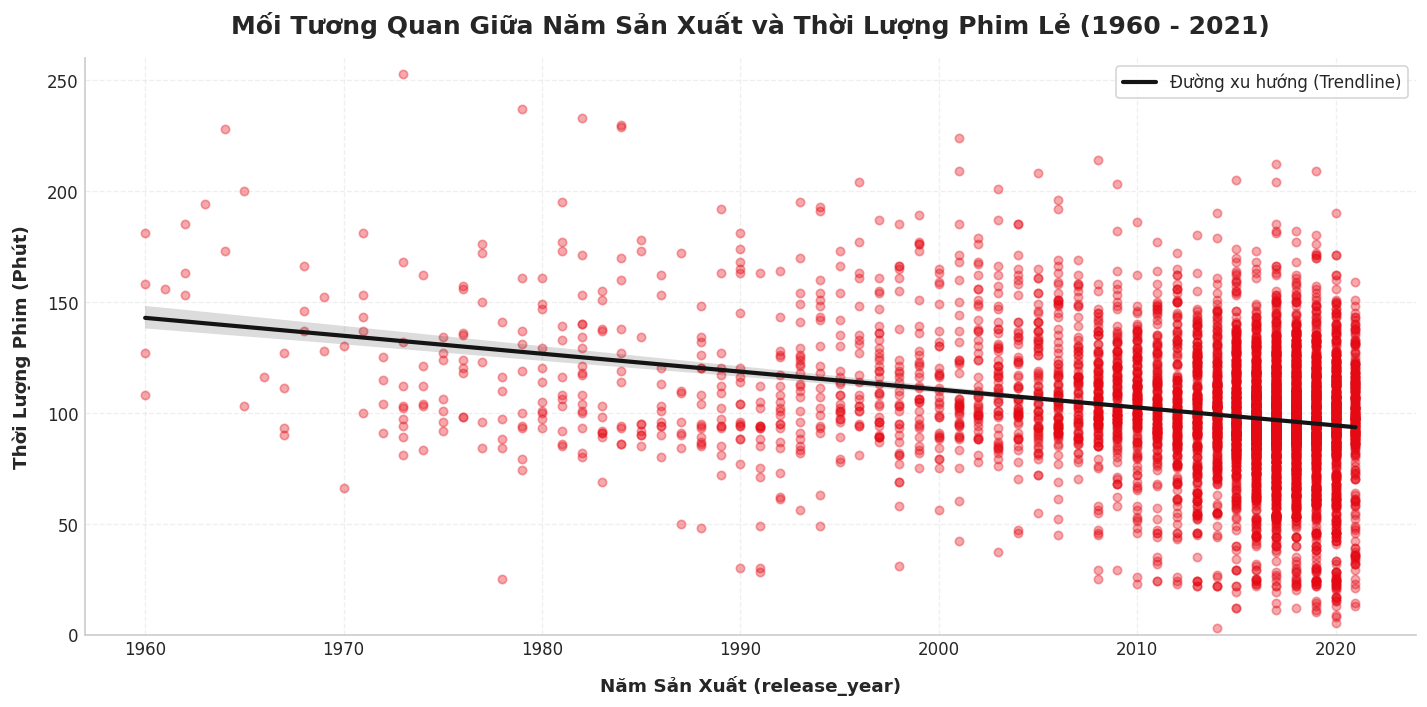

In [18]:
# Chart 16: Scatter Plot - Release Year vs Movie Duration
plt.figure(figsize=(12, 6))

movies_scatter = df[(df['type'] == 'Movie') & (df['duration_unit'] == 'min') & (df['release_year'] >= 1960)]

sns.regplot(data=movies_scatter, x='release_year', y='duration_int',
            scatter_kws={'alpha': 0.35, 'color': NETFLIX_RED, 's': 25},
            line_kws={'color': NETFLIX_BLACK, 'linewidth': 2.5, 'label': 'Đường xu hướng (Trendline)'})

plt.title('Mối Tương Quan Giữa Năm Sản Xuất và Thời Lượng Phim Lẻ (1960 - 2021)', fontsize=15, pad=15)
plt.xlabel('Năm Sản Xuất (release_year)', labelpad=10)
plt.ylabel('Thời Lượng Phim (Phút)', labelpad=10)
plt.ylim(0, 260)
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 17: Treemap — Hệ Sinh Thái Nội Dung Phân Cấp: Quốc Gia × Thể Loại
- **Mục tiêu:** Trực quan hóa cấu trúc phân tầng danh mục: Top quốc gia và cơ cấu thể loại tương ứng của từng quốc gia.
- **Thấu cảm dữ liệu:** Treemap thể hiện rõ bản sắc văn hóa từng thị trường:
  - **Hoa Kỳ:** Thống trị bởi Dramas, Comedies, và các chương trình Stand-Up Comedy độc quyền.
  - **Ấn Độ:** Gần như tuyệt đối là Bollywood Dramas và International Comedies.
  - **Nhật Bản:** Phân nhánh Anime Series và Anime Features chiếm phần lớn thị phần.
  - **Hàn Quốc:** Dẫn đầu bởi International TV Shows và K-Dramas lãng mạn.
- **Thiết kế trực quan:** Treemap phân tầng tương tác (Interactive Hierarchical Treemap) bằng Plotly.


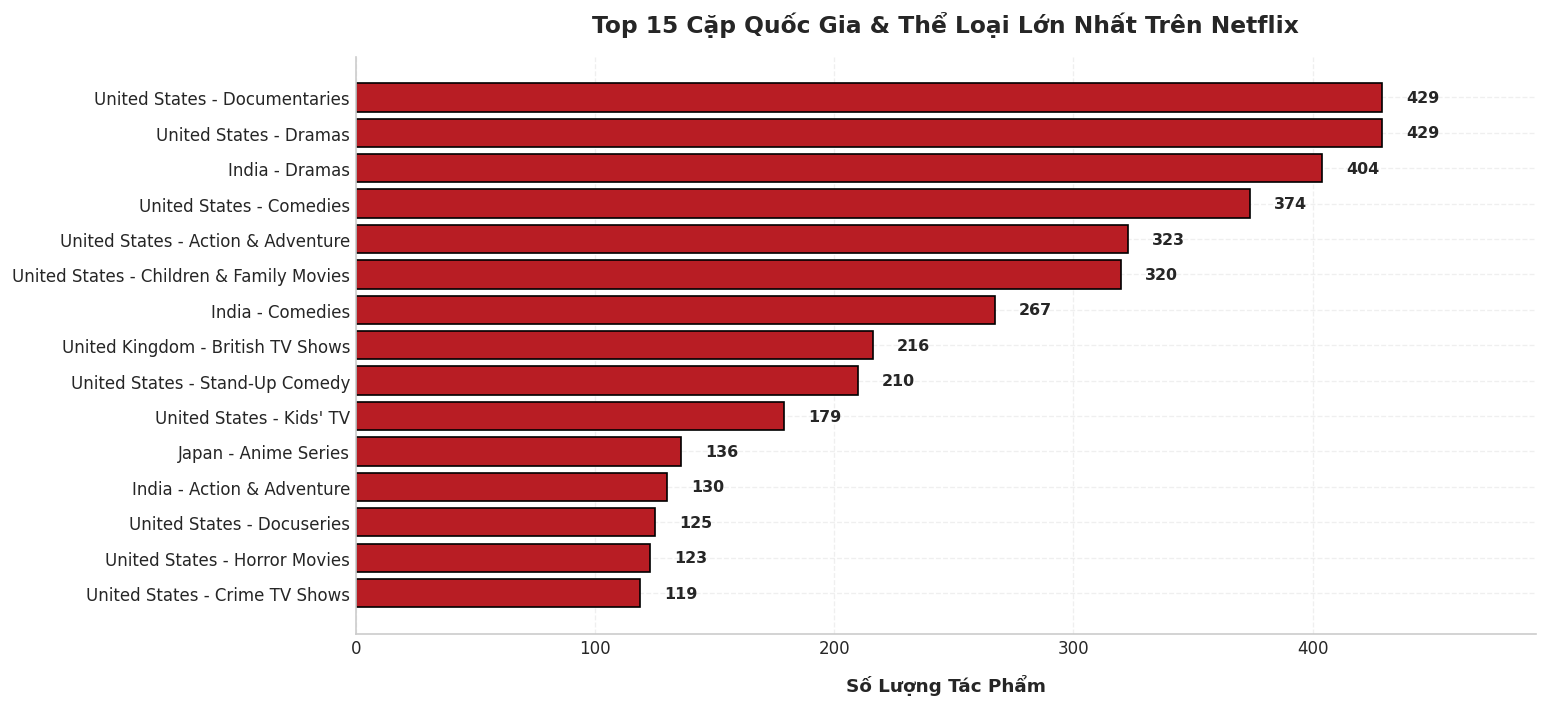

In [19]:
# Chart 17: Treemap Quốc gia -> Thể loại
top_6_countries = df[~df['primary_country'].isin(['Unknown', ''])]['primary_country'].value_counts().head(6).index
df_treemap = df[df['primary_country'].isin(top_6_countries)]

treemap_data = df_treemap.groupby(['primary_country', 'primary_genre']).size().reset_index(name='count')
treemap_data = treemap_data.sort_values(by=['primary_country', 'count'], ascending=[True, False])

if HAS_PLOTLY:
    fig = px.treemap(
        treemap_data,
        path=['primary_country', 'primary_genre'],
        values='count',
        color='count',
        color_continuous_scale='Reds',
        title='Hệ Sinh Thái Nội Dung Netflix Phân Tầng: Quốc Gia → Thể Loại (Treemap)'
    )
    fig.update_layout(margin=dict(l=10, r=10, t=50, b=10))
    fig.show()

# Biểu đồ bổ trợ
plt.figure(figsize=(13, 6))
top_pairs = treemap_data.nlargest(15, 'count')
plt.barh([f"{r['primary_country']} - {r['primary_genre']}" for _, r in top_pairs.iloc[::-1].iterrows()],
         top_pairs['count'].iloc[::-1], color=NETFLIX_DARK_RED, edgecolor='black')
for i, v in enumerate(top_pairs['count'].iloc[::-1]):
    plt.text(v + 10, i, f"{v:,}", va='center', fontsize=9.5, weight='bold')
plt.title('Top 15 Cặp Quốc Gia & Thể Loại Lớn Nhất Trên Netflix', fontsize=14, pad=15)
plt.xlabel('Số Lượng Tác Phẩm', labelpad=10)
plt.xlim(0, max(top_pairs['count']) * 1.15)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


### 📊 Biểu đồ 18: Word Cloud — Khám Phá Các Từ Khóa Cốt Lõi Trong Cốt Truyện (Description NLP)
- **Mục tiêu:** Bóc tách các chủ đề và môtíp cảm xúc thường gặp nhất trong phần mô tả tóm tắt nội dung phim của Netflix.
- **Thấu cảm dữ liệu:** Sau khi lọc bỏ các hư từ tiếng Anh (stopwords) và các từ định danh phổ thông, những từ khóa nổi trội nhất là: **life (cuộc sống), love (tình yêu), family (gia đình), world (thế giới), friends (bạn bè), young (tuổi trẻ), murder (vụ án mạng), secret (bí mật), woman (phụ nữ), new (mới)**. Điều này cho thấy cốt truyện trên Netflix xoay quanh sâu sắc hai thái cực: tình cảm gia đình/lãng mạn và các yếu tố trinh thám/kịch tính.
- **Thiết kế trực quan:** Word Cloud độ phân giải cao với bảng màu nóng Netflix Reds/Fire.


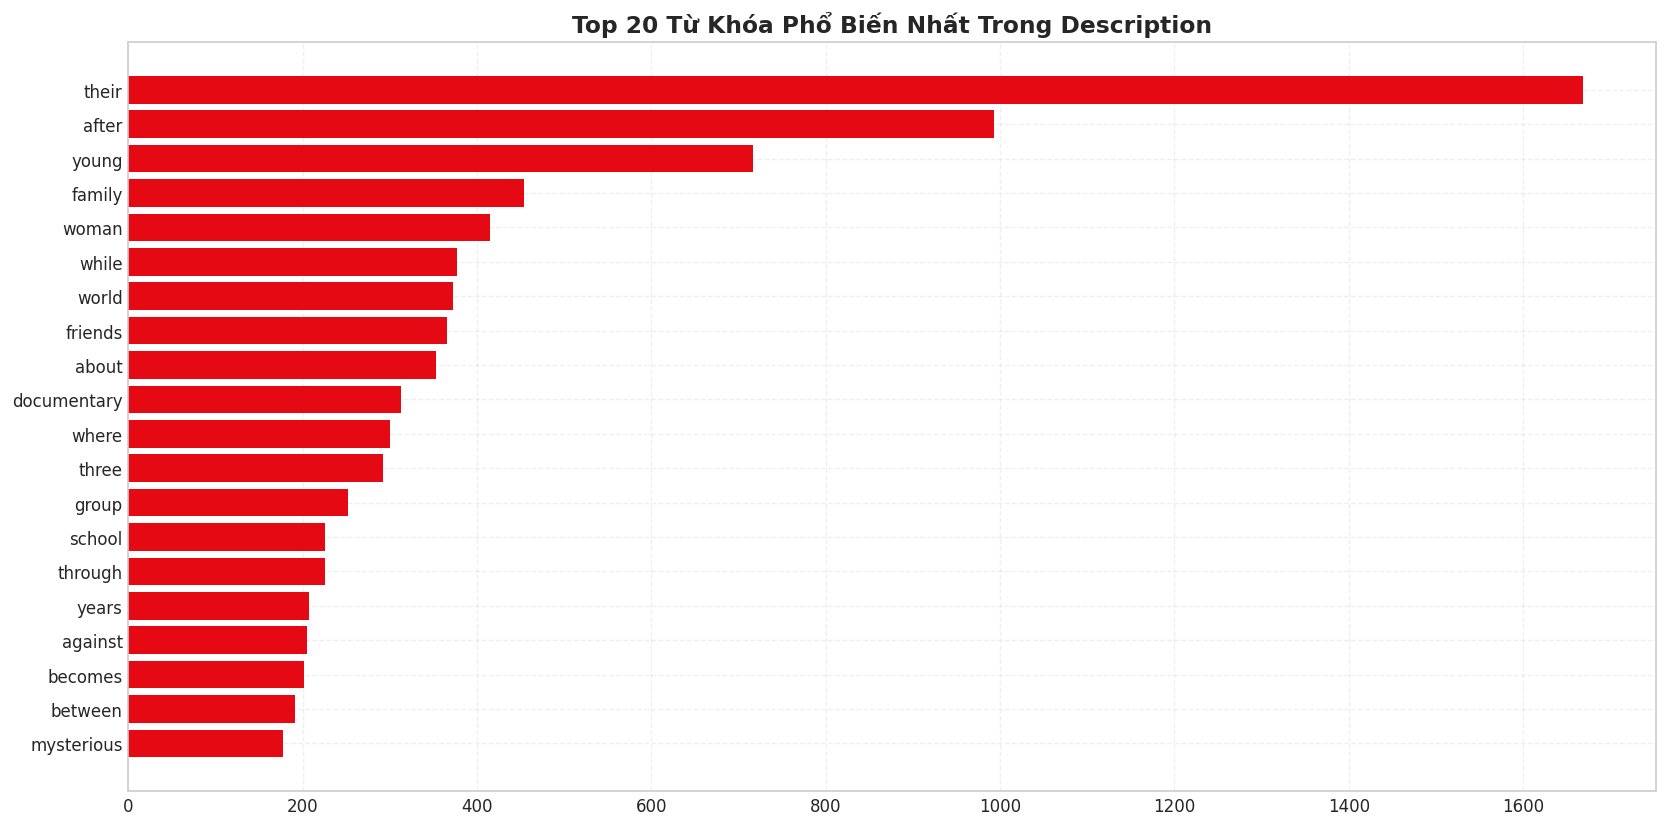

In [20]:
# Chart 18: Word Cloud từ mô tả cốt truyện (description)
plt.figure(figsize=(14, 7))

all_descriptions = ' '.join(df['description'].dropna().astype(str))

custom_stopwords = set(STOPWORDS) if HAS_WORDCLOUD else set()
custom_stopwords.update([
    'movie', 'show', 'series', 'film', 'one', 'two', 'find', 'finds', 'take', 'takes',
    'make', 'makes', 'will', 'see', 'must', 'help', 'helps', 'live', 'lives', 'way'
])

if HAS_WORDCLOUD:
    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color='black',
        colormap='autumn',
        stopwords=custom_stopwords,
        max_words=150,
        contour_width=2,
        contour_color=NETFLIX_RED,
        random_state=42
    ).generate(all_descriptions)

    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud: Những Từ Khóa Cốt Lõi Xuất Hiện Nhiều Nhất Trong Cốt Truyện Netflix',
              fontsize=15, pad=20, weight='bold', color=NETFLIX_BLACK)
else:
    from collections import Counter
    words = [w.lower() for w in all_descriptions.split() if len(w) > 4 and w.lower() not in custom_stopwords]
    top_words = dict(Counter(words).most_common(20))
    plt.barh(list(top_words.keys())[::-1], list(top_words.values())[::-1], color=NETFLIX_RED)
    plt.title('Top 20 Từ Khóa Phổ Biến Nhất Trong Description', fontsize=14)

plt.tight_layout()
plt.show()


---
# 🎯 Tổng Kết Những Phát Hiện Trọng Tâm (Executive Summary)

Sau khi trực quan hóa toàn diện 18 biểu đồ trên tập dữ liệu 8.807 tác phẩm Netflix, Nhóm 8 rút ra các nhận định chiến lược sau:

| STT | Khía Cạnh | Phát Hiện Cốt Lõi | Ý Nghĩa Chiến Lược |
|:---:|:---|:---|:---|
| **1** | **Cơ cấu sản phẩm** | Phim lẻ chiếm 69.6%, Phim bộ chiếm 30.4%. | Phim lẻ lôi kéo người dùng mới, TV Show duy trì đăng ký thuê bao định kỳ. |
| **2** | **Địa lý sản xuất** | Mỹ (36.5%) & Ấn Độ (11.4%) là hai nguồn cung khổng lồ. | Tận dụng điện ảnh Bollywood & Hollywood để chiếm lĩnh thị trường toàn cầu. |
| **3** | **Điểm uốn phát triển** | Tăng trưởng phi mã từ 2016 và chạm đỉnh năm 2019 (2.016 phim). | Đại dịch COVID-19 làm chậm tốc độ sản xuất nhưng thúc đẩy tối ưu hóa danh mục. |
| **4** | **Yếu tố mùa vụ** | Tháng 7 và Tháng 12 là hai tháng cao điểm phát hành nội dung. | Tập trung chiến dịch tiếp thị bom tấn vào kỳ nghỉ hè và Giáng sinh. |
| **5** | **Khán giả mục tiêu** | Hơn 61% nội dung dán nhãn 14+ trở lên (TV-MA chiếm 36.5%). | Netflix là nền tảng giải trí tập trung cao vào người trưởng thành. |
| **6** | **Thời lượng chuẩn** | Thời lượng phim tập trung chặt chẽ ở 80 - 120 phút (trung bình 99.6 phút). | Tiêu chuẩn vàng phù hợp thói quen xem phim trực tuyến tại gia. |
| **7** | **Khắc nghiệt của Series** | 67% TV Shows kết thúc sau Mùa 1. | Netflix thực hiện cắt giảm quyết liệt với các series không đạt chỉ số retention. |
| **8** | **Chủ đề cốt lõi** | Tình cảm (love, family) song hành cùng giật gân (murder, secret). | Công thức kịch bản đảm bảo sự lôi cuốn cho mọi tệp người xem. |

---
**Nhóm 8 - KADA** xin chân thành cảm ơn!
